In [1]:
from pathlib import Path
import importlib
import sys

import ee
import pandas as pd


# ============================================================
# Repository setup
# ============================================================

def find_repo_root(start=None):
    current = Path(start or Path.cwd()).resolve()

    for candidate in [current, *current.parents]:
        if (candidate / "pyproject.toml").exists():
            return candidate

    raise FileNotFoundError(
        "Repository root not found."
    )


REPO_ROOT = find_repo_root()
SRC_PATH = REPO_ROOT / "src"

if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))


# ============================================================
# Earth Engine project
# ============================================================

EE_PROJECT = "ee-sneiderquintero"

ee.Initialize(
    project=EE_PROJECT
)

print(
    "Earth Engine project:",
    EE_PROJECT,
)


# ============================================================
# Repository modules
# ============================================================

import et_downscaling.albedo as albedo_module
import et_downscaling.hls as hls_module
import et_downscaling.modis as modis_module
import et_downscaling.sentinel2 as sentinel2_module

importlib.reload(albedo_module)
importlib.reload(hls_module)
importlib.reload(modis_module)
importlib.reload(sentinel2_module)


# ============================================================
# Core spatial objects
# ============================================================

modis_inputs = (
    modis_module
    .build_modis_inputs()
)

station_footprints = ee.FeatureCollection(
    modis_inputs["station_footprints"]
)

analysis_geometry = (
    station_footprints
    .geometry()
)

station_count = (
    station_footprints
    .size()
    .getInfo()
)

print(
    "Stations:",
    station_count,
)


# ============================================================
# Optical collections
# ============================================================

s2_collection = (
    sentinel2_module
    .get_sentinel2_collection(
        station_footprints
    )
)

hls_collection = (
    hls_module
    .get_hls_collection(
        station_footprints
    )
)

hls_s30_collection = (
    hls_collection
    .filter(
        ee.Filter.eq(
            "sensor",
            "S30",
        )
    )
)

hls_l30_collection = (
    hls_collection
    .filter(
        ee.Filter.eq(
            "sensor",
            "L30",
        )
    )
)


# ============================================================
# Retrieve only compact metadata once
# ============================================================

s2_count = (
    s2_collection
    .size()
    .getInfo()
)

hls_s30_count = (
    hls_s30_collection
    .size()
    .getInfo()
)

hls_l30_count = (
    hls_l30_collection
    .size()
    .getInfo()
)

s2_dates = set(
    s2_collection
    .aggregate_array("date_key")
    .distinct()
    .getInfo()
)

hls_s30_dates = set(
    hls_s30_collection
    .aggregate_array("date_key")
    .distinct()
    .getInfo()
)

common_dates = sorted(
    s2_dates
    & hls_s30_dates
)


# ============================================================
# Session summary
# ============================================================

print()
print("SESSION READY")
print("=============")

print(
    "S2 products:",
    s2_count,
)

print(
    "HLS-S30 products:",
    hls_s30_count,
)

print(
    "HLS-L30 products:",
    hls_l30_count,
)

print(
    "S2 dates:",
    len(s2_dates),
)

print(
    "HLS-S30 dates:",
    len(hls_s30_dates),
)

print(
    "Same-day S2 / HLS-S30 dates:",
    len(common_dates),
)

print(
    "First same-day date:",
    common_dates[0],
)

print(
    "Last same-day date:",
    common_dates[-1],
)

Earth Engine project: ee-sneiderquintero
Stations: 5

SESSION READY
S2 products: 439
HLS-S30 products: 3161
HLS-L30 products: 216
S2 dates: 217
HLS-S30 dates: 638
Same-day S2 / HLS-S30 dates: 207
First same-day date: 2021-01-03
Last same-day date: 2023-12-29


In [2]:
# ============================================================
# Single-date smoke test
# ============================================================

test_date = common_dates[0]

print(
    "Test date:",
    test_date,
)


# HLS-S30 same day
hls_day = (
    hls_s30_collection
    .filter(
        ee.Filter.eq(
            "date_key",
            test_date,
        )
    )
)

hls_reference = ee.Image(
    hls_day.first()
)

hls_projection = (
    hls_reference
    .select("B11")
    .projection()
)

hls_image = (
    hls_module
    .build_hls_medoid(
        hls_day,
        analysis_geometry,
    )
    .setDefaultProjection(
        hls_projection
    )
)


# Sentinel-2 same day
s2_day = (
    s2_collection
    .filter(
        ee.Filter.eq(
            "date_key",
            test_date,
        )
    )
)

s2_reference = ee.Image(
    s2_day.first()
)

s2_projection = (
    s2_reference
    .select("B11")
    .projection()
)

s2_image_20m = (
    sentinel2_module
    .build_s2_medoid(
        s2_day,
        analysis_geometry,
    )
    .setDefaultProjection(
        s2_projection
    )
)

s2_image_30m = (
    s2_image_20m
    .reduceResolution(
        reducer=ee.Reducer.mean(),
        maxPixels=16,
    )
    .reproject(
        hls_projection
    )
    .toFloat()
)


# Albedo
s2_albedo = (
    albedo_module
    .calculate_s2_albedo(
        s2_image_30m
    )
)

hls_albedo = (
    albedo_module
    .calculate_hls_albedo(
        hls_image
    )
)


# Common valid pixels
common_bands = [
    "Blue",
    "Green",
    "Red",
    "NIR",
    "SWIR1",
    "SWIR2",
]

hls_valid = (
    hls_image
    .select(common_bands)
    .mask()
    .reduce(
        ee.Reducer.min()
    )
)

s2_valid = (
    s2_image_30m
    .select(common_bands)
    .mask()
    .reduce(
        ee.Reducer.min()
    )
)

common_valid = (
    hls_valid
    .And(s2_valid)
)


# Test on first station footprint
test_geometry = (
    ee.Feature(
        station_footprints.first()
    )
    .geometry()
)

comparison = (
    s2_albedo
    .rename("S2_Albedo")
    .addBands(
        hls_albedo.rename(
            "HLS_Albedo"
        )
    )
    .updateMask(
        common_valid
    )
)

stats = (
    comparison
    .reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=test_geometry,
        crs=hls_projection,
        scale=30,
        maxPixels=1e6,
        tileScale=4,
    )
    .getInfo()
)

print(
    "HLS observations:",
    hls_day.size().getInfo(),
)

print(
    "S2 observations:",
    s2_day.size().getInfo(),
)

print(
    "Mean albedo:",
    stats,
)

print(
    "Smoke test completed."
)

Test date: 2021-01-03
HLS observations: 2
S2 observations: 2
Mean albedo: {'HLS_Albedo': 0.1452575456088299, 'S2_Albedo': 0.1574151002082916}
Smoke test completed.


Dates to evaluate: 207
Station footprints: 5
Minimum common coverage: 80.0
No checkpoint found.
1/207 | 2021-01-03
2/207 | 2021-01-08
3/207 | 2021-01-13
4/207 | 2021-01-18
5/207 | 2021-01-23
6/207 | 2021-01-28
7/207 | 2021-02-02
8/207 | 2021-02-07
9/207 | 2021-02-12
10/207 | 2021-02-17
11/207 | 2021-02-22
12/207 | 2021-02-27
13/207 | 2021-03-04
14/207 | 2021-03-09
15/207 | 2021-03-14
16/207 | 2021-03-19
17/207 | 2021-03-24
18/207 | 2021-03-29
19/207 | 2021-04-08
20/207 | 2021-04-13
21/207 | 2021-04-23
22/207 | 2021-05-03
23/207 | 2021-05-08
24/207 | 2021-05-13
25/207 | 2021-05-23
26/207 | 2021-05-28
27/207 | 2021-06-12
28/207 | 2021-06-17
29/207 | 2021-06-22
30/207 | 2021-06-27
31/207 | 2021-07-02
32/207 | 2021-07-07
33/207 | 2021-07-12
34/207 | 2021-07-17
35/207 | 2021-07-22
36/207 | 2021-07-27
37/207 | 2021-08-01
38/207 | 2021-08-06
39/207 | 2021-08-11
40/207 | 2021-08-16
41/207 | 2021-08-21
42/207 | 2021-08-26
43/207 | 2021-09-10
44/207 | 2021-09-15
45/207 | 2021-09-20
46/207 | 2021

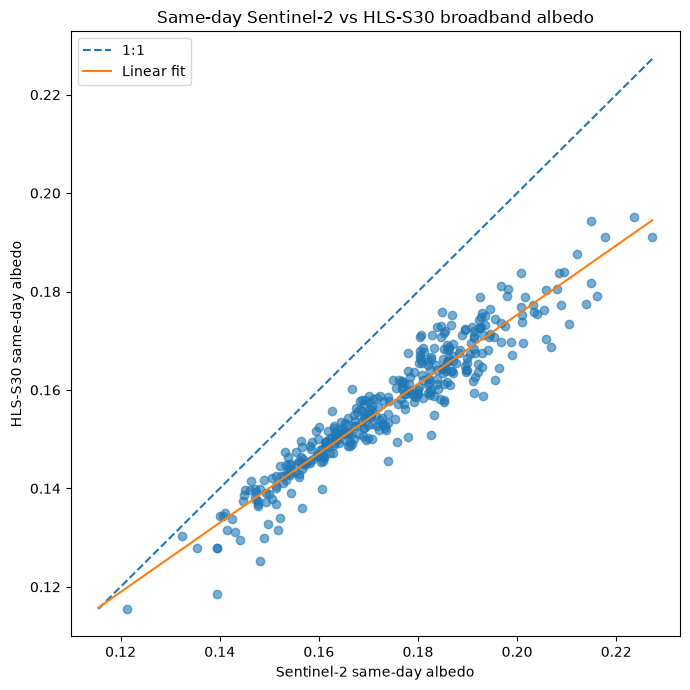


FILES SAVED
C:\Users\User\Desktop\cristian\GEE\26-et-downscaling-fundacion\outputs\diagnostics\_albedo_same_day_s2_hlss30_checkpoint_v1.csv
C:\Users\User\Desktop\cristian\GEE\26-et-downscaling-fundacion\outputs\diagnostics\albedo_same_day_s2_hlss30_pairs.csv
C:\Users\User\Desktop\cristian\GEE\26-et-downscaling-fundacion\outputs\diagnostics\albedo_same_day_s2_hlss30_metrics.csv
C:\Users\User\Desktop\cristian\GEE\26-et-downscaling-fundacion\outputs\diagnostics\albedo_same_day_s2_hlss30_by_station.csv
C:\Users\User\Desktop\cristian\GEE\26-et-downscaling-fundacion\outputs\diagnostics\albedo_same_day_s2_hlss30_outliers.csv
C:\Users\User\Desktop\cristian\GEE\26-et-downscaling-fundacion\outputs\diagnostics\albedo_same_day_s2_hlss30.png


In [3]:
from pathlib import Path
import time

import ee
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# ============================================================
# Configuration
# ============================================================

MIN_COMMON_COVERAGE_PCT = 80.0
MAX_RETRIES = 5

COMMON_BANDS = [
    "Blue",
    "Green",
    "Red",
    "NIR",
    "SWIR1",
    "SWIR2",
]

# NIR_Broad is also required because the S2 albedo equation
# uses B8 in addition to the common comparison bands.
S2_REQUIRED_BANDS = [
    "Blue",
    "Green",
    "Red",
    "NIR_Broad",
    "NIR",
    "SWIR1",
    "SWIR2",
]

COMPARISON_VARIABLES = [
    "Blue",
    "Green",
    "Red",
    "NIR",
    "SWIR1",
    "SWIR2",
    "Albedo",
]


# ============================================================
# Output paths
# ============================================================

DIAGNOSTIC_DIR = (
    REPO_ROOT
    / "outputs"
    / "diagnostics"
)

DIAGNOSTIC_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

CHECKPOINT_PATH = (
    DIAGNOSTIC_DIR
    / "_albedo_same_day_s2_hlss30_checkpoint_v1.csv"
)

PAIR_OUTPUT_PATH = (
    DIAGNOSTIC_DIR
    / "albedo_same_day_s2_hlss30_pairs.csv"
)

METRICS_OUTPUT_PATH = (
    DIAGNOSTIC_DIR
    / "albedo_same_day_s2_hlss30_metrics.csv"
)

STATION_OUTPUT_PATH = (
    DIAGNOSTIC_DIR
    / "albedo_same_day_s2_hlss30_by_station.csv"
)

OUTLIER_OUTPUT_PATH = (
    DIAGNOSTIC_DIR
    / "albedo_same_day_s2_hlss30_outliers.csv"
)

FAILED_OUTPUT_PATH = (
    DIAGNOSTIC_DIR
    / "albedo_same_day_s2_hlss30_failed_dates.csv"
)

FIGURE_PATH = (
    DIAGNOSTIC_DIR
    / "albedo_same_day_s2_hlss30.png"
)


# ============================================================
# Session information
# ============================================================

station_count = (
    station_footprints
    .size()
    .getInfo()
)

print(
    "Dates to evaluate:",
    len(common_dates),
)

print(
    "Station footprints:",
    station_count,
)

print(
    "Minimum common coverage:",
    MIN_COMMON_COVERAGE_PCT,
)


# ============================================================
# Retry helper
# ============================================================

def get_info_with_retry(
    ee_object,
    attempts=MAX_RETRIES,
):
    last_error = None

    for attempt in range(
        1,
        attempts + 1,
    ):
        try:
            return ee_object.getInfo()

        except Exception as error:
            last_error = error

            if attempt == attempts:
                break

            wait_seconds = (
                attempt * 5
            )

            print(
                f"  Retry {attempt}/{attempts} "
                f"after {wait_seconds} s..."
            )

            time.sleep(
                wait_seconds
            )

    raise last_error


# ============================================================
# S2 20 m -> HLS-S30 30 m
# ============================================================

def aggregate_s2_to_hls_grid(
    s2_image,
    s2_projection,
    hls_projection,
):
    s2_image = (
        ee.Image(
            s2_image
        )
        .setDefaultProjection(
            s2_projection
        )
    )

    return (
        s2_image
        .reduceResolution(
            reducer=ee.Reducer.mean(),
            maxPixels=16,
        )
        .reproject(
            hls_projection
        )
        .toFloat()
    )


# ============================================================
# Same-day comparison
# ============================================================

def build_same_day_comparison(
    date_key,
):
    # --------------------------------------------------------
    # HLS-S30
    # --------------------------------------------------------

    hls_day_collection = (
        hls_s30_collection
        .filter(
            ee.Filter.eq(
                "date_key",
                date_key,
            )
        )
    )

    hls_reference = (
        ee.Image(
            hls_day_collection.first()
        )
    )

    hls_projection = (
        hls_reference
        .select(
            "B11"
        )
        .projection()
    )

    hls_image = (
        hls_module
        .build_hls_medoid(
            hls_day_collection,
            analysis_geometry,
        )
        .setDefaultProjection(
            hls_projection
        )
    )

    # --------------------------------------------------------
    # Sentinel-2
    # --------------------------------------------------------

    s2_day_collection = (
        s2_collection
        .filter(
            ee.Filter.eq(
                "date_key",
                date_key,
            )
        )
    )

    s2_reference = (
        ee.Image(
            s2_day_collection.first()
        )
    )

    s2_projection = (
        s2_reference
        .select(
            "B11"
        )
        .projection()
    )

    s2_image_20m = (
        sentinel2_module
        .build_s2_medoid(
            s2_day_collection,
            analysis_geometry,
        )
        .setDefaultProjection(
            s2_projection
        )
    )

    s2_image_30m = (
        aggregate_s2_to_hls_grid(
            s2_image_20m,
            s2_projection,
            hls_projection,
        )
    )

    # --------------------------------------------------------
    # Common valid support
    # --------------------------------------------------------

    hls_valid = (
        hls_image
        .select(
            COMMON_BANDS
        )
        .mask()
        .reduce(
            ee.Reducer.min()
        )
    )

    s2_valid = (
        s2_image_30m
        .select(
            S2_REQUIRED_BANDS
        )
        .mask()
        .reduce(
            ee.Reducer.min()
        )
    )

    common_valid = (
        hls_valid
        .And(
            s2_valid
        )
        .rename(
            "common_valid"
        )
    )

    # --------------------------------------------------------
    # Broadband albedo
    # --------------------------------------------------------

    s2_albedo = (
        albedo_module
        .calculate_s2_albedo(
            s2_image_30m
        )
    )

    hls_albedo = (
        albedo_module
        .calculate_hls_albedo(
            hls_image
        )
    )

    # --------------------------------------------------------
    # Comparison stack
    # --------------------------------------------------------

    s2_stack = (
        s2_image_30m
        .select(
            COMMON_BANDS
        )
        .addBands(
            s2_albedo
        )
        .rename(
            [
                "S2_Blue",
                "S2_Green",
                "S2_Red",
                "S2_NIR",
                "S2_SWIR1",
                "S2_SWIR2",
                "S2_Albedo",
            ]
        )
    )

    hls_stack = (
        hls_image
        .select(
            COMMON_BANDS
        )
        .addBands(
            hls_albedo
        )
        .rename(
            [
                "HLS_Blue",
                "HLS_Green",
                "HLS_Red",
                "HLS_NIR",
                "HLS_SWIR1",
                "HLS_SWIR2",
                "HLS_Albedo",
            ]
        )
    )

    comparison = (
        s2_stack
        .addBands(
            hls_stack
        )
        .updateMask(
            common_valid
        )
        .setDefaultProjection(
            hls_projection
        )
    )

    # --------------------------------------------------------
    # Common valid area
    # --------------------------------------------------------

    valid_area_image = (
        ee.Image
        .pixelArea()
        .updateMask(
            common_valid
        )
        .rename(
            "valid_area_m2"
        )
    )

    # --------------------------------------------------------
    # Reduce each MODIS footprint
    # --------------------------------------------------------

    def summarize_footprint(
        feature,
    ):
        feature = ee.Feature(
            feature
        )

        geometry = (
            feature.geometry()
        )

        means = (
            comparison
            .reduceRegion(
                reducer=ee.Reducer.mean(),
                geometry=geometry,
                crs=hls_projection,
                scale=30,
                maxPixels=1e6,
                tileScale=4,
            )
        )

        valid_area_raw = (
            valid_area_image
            .reduceRegion(
                reducer=ee.Reducer.sum(),
                geometry=geometry,
                crs=hls_projection,
                scale=30,
                maxPixels=1e6,
                tileScale=4,
            )
            .get(
                "valid_area_m2"
            )
        )

        valid_area = ee.Number(
            ee.Algorithms.If(
                ee.Algorithms.IsEqual(
                    valid_area_raw,
                    None,
                ),
                0,
                valid_area_raw,
            )
        )

        footprint_area = (
            geometry.area(
                maxError=1
            )
        )

        common_coverage_pct = (
            valid_area
            .divide(
                footprint_area
            )
            .multiply(
                100
            )
        )

        return (
            feature
            .set(
                means
            )
            .set(
                {
                    "date_key":
                        date_key,

                    "common_valid_area_m2":
                        valid_area,

                    "common_coverage_pct":
                        common_coverage_pct,
                }
            )
        )

    return (
        station_footprints
        .map(
            summarize_footprint
        )
    )


# ============================================================
# Load checkpoint
# ============================================================

if CHECKPOINT_PATH.exists():

    observations = (
        pd.read_csv(
            CHECKPOINT_PATH
        )
    )

    observations[
        "date_key"
    ] = (
        observations[
            "date_key"
        ]
        .astype(str)
    )

    print(
        "Checkpoint loaded:",
        len(observations),
        "rows",
    )

else:

    observations = (
        pd.DataFrame()
    )

    print(
        "No checkpoint found."
    )


# ============================================================
# Process all same-day dates
# ============================================================

failed_dates = []

for index, date_key in enumerate(
    common_dates,
    start=1,
):

    # --------------------------------------------------------
    # Skip complete dates already stored
    # --------------------------------------------------------

    if not observations.empty:

        existing = (
            observations[
                observations[
                    "date_key"
                ].eq(
                    date_key
                )
            ]
        )

        if len(existing) == station_count:

            print(
                f"{index}/{len(common_dates)} | "
                f"{date_key} | cached"
            )

            continue

        # Remove incomplete version before retrying.
        observations = (
            observations[
                ~observations[
                    "date_key"
                ].eq(
                    date_key
                )
            ]
            .copy()
        )

    print(
        f"{index}/{len(common_dates)} | "
        f"{date_key}"
    )

    try:

        comparison_fc = (
            build_same_day_comparison(
                date_key
            )
        )

        information = (
            get_info_with_retry(
                comparison_fc
            )
        )

        rows = []

        for feature in information[
            "features"
        ]:

            properties = (
                feature[
                    "properties"
                ]
            )

            row = {
                "date_key":
                    date_key,

                "station":
                    properties.get(
                        "station"
                    ),

                "station_id":
                    properties.get(
                        "station_id"
                    ),

                "common_coverage_pct":
                    properties.get(
                        "common_coverage_pct"
                    ),
            }

            for variable in (
                COMPARISON_VARIABLES
            ):

                row[
                    f"S2_{variable}"
                ] = properties.get(
                    f"S2_{variable}"
                )

                row[
                    f"HLS_{variable}"
                ] = properties.get(
                    f"HLS_{variable}"
                )

            rows.append(
                row
            )

        period_table = (
            pd.DataFrame(
                rows
            )
        )

        observations = (
            pd.concat(
                [
                    observations,
                    period_table,
                ],
                ignore_index=True,
            )
        )

        # Save after every successful date.
        observations.to_csv(
            CHECKPOINT_PATH,
            index=False,
        )

    except Exception as error:

        print(
            "  FAILED:",
            str(error)[:300],
        )

        failed_dates.append(
            {
                "date_key":
                    date_key,

                "error":
                    str(error),
            }
        )

        pd.DataFrame(
            failed_dates
        ).to_csv(
            FAILED_OUTPUT_PATH,
            index=False,
        )

        continue


# ============================================================
# Basic processing summary
# ============================================================

print()
print(
    "PROCESSING SUMMARY"
)
print(
    "=================="
)

print(
    "Stored footprint observations:",
    len(observations),
)

print(
    "Stored dates:",
    observations[
        "date_key"
    ].nunique(),
)

print(
    "Failed dates in this run:",
    len(failed_dates),
)


# ============================================================
# Common coverage filter
# ============================================================

paired = (
    observations[
        observations[
            "common_coverage_pct"
        ]
        .ge(
            MIN_COMMON_COVERAGE_PCT
        )
    ]
    .copy()
)

required_columns = []

for variable in (
    COMPARISON_VARIABLES
):
    required_columns.extend(
        [
            f"S2_{variable}",
            f"HLS_{variable}",
        ]
    )

paired = (
    paired
    .dropna(
        subset=required_columns
    )
    .reset_index(
        drop=True
    )
)


print()
print(
    "VALID COMPARISON SAMPLE"
)
print(
    "======================="
)

print(
    "Footprint pairs:",
    len(paired),
)

print(
    "Unique dates:",
    paired[
        "date_key"
    ].nunique(),
)


# ============================================================
# Agreement metrics
# ============================================================

def calculate_agreement_metrics(
    table,
    variable,
):

    s2_values = (
        table[
            f"S2_{variable}"
        ]
        .astype(float)
        .to_numpy()
    )

    hls_values = (
        table[
            f"HLS_{variable}"
        ]
        .astype(float)
        .to_numpy()
    )

    difference = (
        hls_values
        - s2_values
    )

    n = len(
        difference
    )

    mean_s2 = float(
        np.mean(
            s2_values
        )
    )

    mean_hls = float(
        np.mean(
            hls_values
        )
    )

    bias = float(
        np.mean(
            difference
        )
    )

    mae = float(
        np.mean(
            np.abs(
                difference
            )
        )
    )

    rmse = float(
        np.sqrt(
            np.mean(
                difference ** 2
            )
        )
    )

    relative_bias_pct = (
        100.0
        * bias
        / mean_s2
        if mean_s2 != 0
        else np.nan
    )

    if (
        n > 1
        and np.std(
            s2_values
        ) > 0
        and np.std(
            hls_values
        ) > 0
    ):

        pearson_r = float(
            np.corrcoef(
                s2_values,
                hls_values,
            )[0, 1]
        )

        regression_r2 = (
            pearson_r ** 2
        )

        slope, intercept = (
            np.polyfit(
                s2_values,
                hls_values,
                1,
            )
        )

        covariance = (
            np.cov(
                s2_values,
                hls_values,
                ddof=1,
            )[0, 1]
        )

        variance_s2 = (
            np.var(
                s2_values,
                ddof=1,
            )
        )

        variance_hls = (
            np.var(
                hls_values,
                ddof=1,
            )
        )

        lin_ccc = (
            2.0
            * covariance
            / (
                variance_s2
                + variance_hls
                + (
                    mean_s2
                    - mean_hls
                ) ** 2
            )
        )

    else:

        pearson_r = np.nan
        regression_r2 = np.nan
        slope = np.nan
        intercept = np.nan
        lin_ccc = np.nan

    return {
        "variable":
            variable,

        "n":
            n,

        "mean_s2":
            mean_s2,

        "mean_hls":
            mean_hls,

        "bias_hls_minus_s2":
            bias,

        "relative_bias_pct":
            relative_bias_pct,

        "mae":
            mae,

        "rmse":
            rmse,

        "pearson_r":
            pearson_r,

        "regression_r2":
            regression_r2,

        "slope":
            slope,

        "intercept":
            intercept,

        "lin_ccc":
            lin_ccc,
    }


metrics = pd.DataFrame(
    [
        calculate_agreement_metrics(
            paired,
            variable,
        )
        for variable in (
            COMPARISON_VARIABLES
        )
    ]
)


print()
print(
    "SAME-DAY S2 vs HLS-S30 AGREEMENT"
)
print(
    "================================"
)

print(
    metrics
    .round(5)
    .to_string(
        index=False
    )
)


# ============================================================
# Albedo by station
# ============================================================

paired[
    "Albedo_difference"
] = (
    paired[
        "HLS_Albedo"
    ]
    - paired[
        "S2_Albedo"
    ]
)

station_summary = (
    paired
    .groupby(
        "station",
        dropna=False,
    )
    .agg(
        n=(
            "Albedo_difference",
            "size",
        ),

        mean_s2=(
            "S2_Albedo",
            "mean",
        ),

        mean_hls=(
            "HLS_Albedo",
            "mean",
        ),

        bias=(
            "Albedo_difference",
            "mean",
        ),

        mae=(
            "Albedo_difference",
            lambda values:
                np.mean(
                    np.abs(
                        values
                    )
                ),
        ),

        rmse=(
            "Albedo_difference",
            lambda values:
                np.sqrt(
                    np.mean(
                        np.asarray(
                            values
                        ) ** 2
                    )
                ),
        ),
    )
    .reset_index()
)


print()
print(
    "ALBEDO BY STATION"
)
print(
    "================="
)

print(
    station_summary
    .round(5)
    .to_string(
        index=False
    )
)


# ============================================================
# Largest albedo disagreements
# ============================================================

paired[
    "Albedo_abs_difference"
] = (
    paired[
        "Albedo_difference"
    ]
    .abs()
)

outliers = (
    paired
    .sort_values(
        "Albedo_abs_difference",
        ascending=False,
    )
    [
        [
            "station",
            "date_key",
            "common_coverage_pct",
            "S2_Albedo",
            "HLS_Albedo",
            "Albedo_difference",
            "Albedo_abs_difference",
        ]
    ]
    .head(15)
)


print()
print(
    "LARGEST ALBEDO DISAGREEMENTS"
)
print(
    "============================"
)

print(
    outliers
    .round(5)
    .to_string(
        index=False
    )
)


# ============================================================
# Save final tables
# ============================================================

paired.to_csv(
    PAIR_OUTPUT_PATH,
    index=False,
)

metrics.to_csv(
    METRICS_OUTPUT_PATH,
    index=False,
)

station_summary.to_csv(
    STATION_OUTPUT_PATH,
    index=False,
)

outliers.to_csv(
    OUTLIER_OUTPUT_PATH,
    index=False,
)


# ============================================================
# Albedo scatter plot
# ============================================================

albedo_metrics = (
    metrics[
        metrics[
            "variable"
        ].eq(
            "Albedo"
        )
    ]
    .iloc[0]
)

x = (
    paired[
        "S2_Albedo"
    ]
    .astype(float)
    .to_numpy()
)

y = (
    paired[
        "HLS_Albedo"
    ]
    .astype(float)
    .to_numpy()
)

plot_min = min(
    np.min(x),
    np.min(y),
)

plot_max = max(
    np.max(x),
    np.max(y),
)

plt.figure(
    figsize=(
        7,
        7,
    )
)

plt.scatter(
    x,
    y,
    alpha=0.6,
)

plt.plot(
    [
        plot_min,
        plot_max,
    ],
    [
        plot_min,
        plot_max,
    ],
    linestyle="--",
    label="1:1",
)

regression_x = (
    np.linspace(
        plot_min,
        plot_max,
        100,
    )
)

regression_y = (
    albedo_metrics[
        "slope"
    ]
    * regression_x
    + albedo_metrics[
        "intercept"
    ]
)

plt.plot(
    regression_x,
    regression_y,
    label="Linear fit",
)

plt.xlabel(
    "Sentinel-2 same-day albedo"
)

plt.ylabel(
    "HLS-S30 same-day albedo"
)

plt.title(
    "Same-day Sentinel-2 vs HLS-S30 broadband albedo"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    FIGURE_PATH,
    dpi=200,
)

plt.show()


# ============================================================
# Output summary
# ============================================================

print()
print(
    "FILES SAVED"
)
print(
    "==========="
)

print(
    CHECKPOINT_PATH
)

print(
    PAIR_OUTPUT_PATH
)

print(
    METRICS_OUTPUT_PATH
)

print(
    STATION_OUTPUT_PATH
)

print(
    OUTLIER_OUTPUT_PATH
)

print(
    FIGURE_PATH
)

if failed_dates:
    print(
        FAILED_OUTPUT_PATH
    )

In [5]:
import importlib
import et_downscaling.reference_et as reference_et_module

importlib.reload(reference_et_module)

<module 'et_downscaling.reference_et' from 'C:\\Users\\User\\Desktop\\cristian\\GEE\\26-et-downscaling-fundacion\\src\\et_downscaling\\reference_et.py'>

In [6]:
from datetime import datetime
import importlib

import ee
import pandas as pd

import et_downscaling.meteorology as meteorology_module
import et_downscaling.modis as modis_module
import et_downscaling.reference_et as reference_et_module


# ============================================================
# Reload current repository code
# ============================================================

importlib.reload(meteorology_module)
importlib.reload(reference_et_module)


# ============================================================
# Earth Engine
# ============================================================

ee.Initialize(
    project="ee-sneiderquintero"
)


# ============================================================
# Test period
# ============================================================

# Exact 8-day interval for the initial physical QA.
# Earth Engine filterDate uses an inclusive start and
# exclusive end.
TEST_PERIOD_START = "2021-01-01"
TEST_PERIOD_END = "2021-01-09"

start_python = datetime.fromisoformat(
    TEST_PERIOD_START
)

end_python = datetime.fromisoformat(
    TEST_PERIOD_END
)

expected_days = (
    end_python
    - start_python
).days


# ============================================================
# Station footprints
# ============================================================

modis_inputs = (
    modis_module
    .build_modis_inputs()
)

station_footprints = (
    ee.FeatureCollection(
        modis_inputs[
            "station_footprints"
        ]
    )
)

print(
    "Stations:",
    station_footprints
    .size()
    .getInfo()
)


# ============================================================
# Meteorology
# ============================================================

print(
    "Building meteorology inputs..."
)

meteorology_inputs = (
    meteorology_module
    .build_meteorology_inputs(
        station_footprints
    )
)


# ============================================================
# Reference ET inputs
# ============================================================

print(
    "Building reference ET inputs..."
)

reference_et_inputs = (
    reference_et_module
    .build_reference_et_inputs(
        station_footprints=(
            station_footprints
        ),
        meteorology_inputs=(
            meteorology_inputs
        ),
        start_date=(
            TEST_PERIOD_START
        ),
        end_date=(
            TEST_PERIOD_END
        ),
    )
)


# ============================================================
# Static footprint support
# ============================================================

station_supports = (
    ee.FeatureCollection(
        reference_et_inputs[
            "station_supports"
        ]
    )
)

support_info = (
    station_supports
    .getInfo()
)

support_rows = []

for feature in support_info[
    "features"
]:
    properties = feature[
        "properties"
    ]

    support_rows.append(
        {
            "station":
                properties.get(
                    "station"
                ),

            "station_id":
                properties.get(
                    "station_id"
                ),

            "elevation_mean_m":
                properties.get(
                    "footprint_mean_elevation_m"
                ),

            "footprint_latitude":
                properties.get(
                    "footprint_centroid_latitude"
                ),

            "footprint_longitude":
                properties.get(
                    "footprint_centroid_longitude"
                ),

            "era5_latitude":
                properties.get(
                    "era5_sampling_latitude"
                ),

            "era5_longitude":
                properties.get(
                    "era5_sampling_longitude"
                ),

            "era5_distance_m":
                properties.get(
                    "era5_sampling_distance_m"
                ),
        }
    )

support_table = pd.DataFrame(
    support_rows
)

print()
print(
    "STATIC SUPPORT"
)
print(
    "=============="
)

print(
    support_table
    .round(3)
    .to_string(
        index=False
    )
)


# ============================================================
# Variables to inspect daily
# ============================================================

QA_BANDS = [
    "Tmin_day_C",
    "Tmax_day_C",
    "Tmean_day_C",
    "ea_day_kPa",
    "Wind10m_mean_ms",
    "Wind2m_mean_ms",
    "Rs_day_MJ_m2",
    "Rso_day_MJ_m2",
    "Rs_Rso",
    "Rn_day_MJ_m2",
    "ETo_mm_day",
    "ETr_mm_day",
]


# ============================================================
# Daily physical QA
# ============================================================

daily_rows = []
period_rows = []

daily_meteorology = (
    ee.ImageCollection(
        reference_et_inputs[
            "daily_meteorology"
        ]
    )
)

era5_projection = (
    reference_et_inputs[
        "era5_projection"
    ]
)

era5_scale = (
    reference_et_inputs[
        "era5_scale"
    ]
)


for support_row in support_rows:

    station = (
        support_row[
            "station"
        ]
    )

    station_id = (
        support_row[
            "station_id"
        ]
    )

    elevation = (
        support_row[
            "elevation_mean_m"
        ]
    )

    latitude = (
        support_row[
            "footprint_latitude"
        ]
    )

    era5_point = (
        ee.Geometry.Point(
            [
                support_row[
                    "era5_longitude"
                ],
                support_row[
                    "era5_latitude"
                ],
            ]
        )
    )

    print()
    print(
        "Processing:",
        station
    )

    # --------------------------------------------------------
    # Daily ETo/ETr
    # --------------------------------------------------------

    daily_period = (
        daily_meteorology
        .filterDate(
            TEST_PERIOD_START,
            TEST_PERIOD_END,
        )
    )

    daily_reference = (
        daily_period.map(
            lambda image:
                reference_et_module
                .calculate_daily_reference_et(
                    image,
                    latitude,
                    elevation,
                )
        )
    )

    daily_count = (
        daily_reference
        .size()
        .getInfo()
    )

    image_list = (
        daily_reference
        .toList(
            daily_count
        )
    )

    daily_features = []

    for index in range(
        daily_count
    ):
        image = ee.Image(
            image_list.get(
                index
            )
        )

        values = (
            image
            .select(
                QA_BANDS
            )
            .reduceRegion(
                reducer=ee.Reducer.first(),
                geometry=era5_point,
                crs=era5_projection,
                scale=era5_scale,
                maxPixels=100,
            )
        )

        feature = (
            ee.Feature(
                None,
                values,
            )
            .set(
                {
                    "station":
                        station,

                    "station_id":
                        station_id,

                    "local_date":
                        image.get(
                            "local_date"
                        ),

                    "era5_hours_total":
                        image.get(
                            "era5_hours_total"
                        ),

                    "elevation_mean_m":
                        elevation,
                }
            )
        )

        daily_features.append(
            feature
        )

    daily_fc = (
        ee.FeatureCollection(
            daily_features
        )
    )

    daily_info = (
        daily_fc
        .getInfo()
    )

    for feature in daily_info[
        "features"
    ]:
        properties = (
            feature[
                "properties"
            ]
        )

        row = {
            "station":
                properties.get(
                    "station"
                ),

            "station_id":
                properties.get(
                    "station_id"
                ),

            "local_date":
                properties.get(
                    "local_date"
                ),

            "era5_hours_total":
                properties.get(
                    "era5_hours_total"
                ),

            "elevation_mean_m":
                properties.get(
                    "elevation_mean_m"
                ),
        }

        for band in QA_BANDS:
            row[
                band
            ] = properties.get(
                band
            )

        if (
            row[
                "ETo_mm_day"
            ]
            is not None
            and row[
                "ETr_mm_day"
            ]
            is not None
            and row[
                "ETo_mm_day"
            ] != 0
        ):
            row[
                "ETr_ETo_ratio"
            ] = (
                row[
                    "ETr_mm_day"
                ]
                / row[
                    "ETo_mm_day"
                ]
            )

        else:
            row[
                "ETr_ETo_ratio"
            ] = None

        daily_rows.append(
            row
        )

    # --------------------------------------------------------
    # Complete MODIS-period ETo/ETr
    # --------------------------------------------------------

    period_properties = (
        reference_et_module
        .get_reference_et_properties(
            period_start=(
                TEST_PERIOD_START
            ),
            period_end=(
                TEST_PERIOD_END
            ),
            station_id=(
                station_id
            ),
            reference_et_inputs=(
                reference_et_inputs
            ),
        )
        .getInfo()
    )

    period_rows.append(
        {
            "station":
                station,

            "station_id":
                station_id,

            "ETo_period_mm":
                period_properties.get(
                    "ETo_period_mm"
                ),

            "ETr_period_mm":
                period_properties.get(
                    "ETr_period_mm"
                ),

            "ETo_mean_mm_day":
                period_properties.get(
                    "ETo_mean_mm_day"
                ),

            "ETr_mean_mm_day":
                period_properties.get(
                    "ETr_mean_mm_day"
                ),

            "ETr_ETo_ratio":
                period_properties.get(
                    "ETr_ETo_ratio"
                ),

            "days_total":
                period_properties.get(
                    "reference_et_days_total"
                ),

            "days_expected":
                period_properties.get(
                    "reference_et_days_expected"
                ),

            "complete_days":
                period_properties.get(
                    "reference_et_complete_days"
                ),

            "reference_et_complete":
                period_properties.get(
                    "reference_et_complete"
                ),

            "elevation_m":
                period_properties.get(
                    "reference_et_elevation_m"
                ),
        }
    )


# ============================================================
# Tables
# ============================================================

daily_table = pd.DataFrame(
    daily_rows
)

period_table = pd.DataFrame(
    period_rows
)


# ============================================================
# Daily QA table
# ============================================================

print()
print(
    "DAILY REFERENCE ET QA"
)
print(
    "===================="
)

print(
    daily_table[
        [
            "station",
            "local_date",
            "era5_hours_total",
            "Tmin_day_C",
            "Tmax_day_C",
            "Wind10m_mean_ms",
            "Wind2m_mean_ms",
            "Rs_day_MJ_m2",
            "Rso_day_MJ_m2",
            "Rs_Rso",
            "Rn_day_MJ_m2",
            "ETo_mm_day",
            "ETr_mm_day",
            "ETr_ETo_ratio",
        ]
    ]
    .round(3)
    .to_string(
        index=False
    )
)


# ============================================================
# Period summary
# ============================================================

print()
print(
    "MODIS-PERIOD REFERENCE ET"
)
print(
    "========================="
)

print(
    period_table
    .round(3)
    .to_string(
        index=False
    )
)


# ============================================================
# Compact physical diagnostics
# ============================================================

print()
print(
    "PHYSICAL QA SUMMARY"
)
print(
    "==================="
)

qa_summary = (
    daily_table
    .groupby(
        "station"
    )
    .agg(
        n_days=(
            "local_date",
            "size",
        ),

        min_hours=(
            "era5_hours_total",
            "min",
        ),

        min_tmin_c=(
            "Tmin_day_C",
            "min",
        ),

        max_tmax_c=(
            "Tmax_day_C",
            "max",
        ),

        mean_wind10_ms=(
            "Wind10m_mean_ms",
            "mean",
        ),

        mean_wind2_ms=(
            "Wind2m_mean_ms",
            "mean",
        ),

        mean_rs_rso=(
            "Rs_Rso",
            "mean",
        ),

        max_rs_rso=(
            "Rs_Rso",
            "max",
        ),

        mean_rn=(
            "Rn_day_MJ_m2",
            "mean",
        ),

        mean_eto=(
            "ETo_mm_day",
            "mean",
        ),

        mean_etr=(
            "ETr_mm_day",
            "mean",
        ),

        mean_etr_eto_ratio=(
            "ETr_ETo_ratio",
            "mean",
        ),
    )
    .reset_index()
)

print(
    qa_summary
    .round(3)
    .to_string(
        index=False
    )
)


# ============================================================
# Automatic QA flags
# ============================================================

flags = []

if (
    daily_table[
        "era5_hours_total"
    ]
    .min()
    < 24
):
    flags.append(
        "Some local days contain fewer than 24 ERA5 hours."
    )

if (
    daily_table[
        "Rs_Rso"
    ]
    .max()
    > 1.0
):
    flags.append(
        "Rs/Rso exceeds 1.0."
    )

if (
    daily_table[
        "Rs_Rso"
    ]
    .min()
    < 0.30
):
    flags.append(
        "Rs/Rso is below the ASCE lower bound before clipping."
    )

if (
    daily_table[
        "Rn_day_MJ_m2"
    ]
    .min()
    < 0
):
    flags.append(
        "Negative daily net radiation was found."
    )

if (
    daily_table[
        "ETo_mm_day"
    ]
    .min()
    < 0
):
    flags.append(
        "Negative daily ETo was found."
    )

if (
    daily_table[
        "ETr_mm_day"
    ]
    .min()
    < 0
):
    flags.append(
        "Negative daily ETr was found."
    )

print()
print(
    "QA FLAGS"
)
print(
    "========"
)

if flags:

    for flag in flags:
        print(
            "-",
            flag
        )

else:
    print(
        "No automatic physical QA flags."
    )


# ============================================================
# Final completeness check
# ============================================================

print()
print(
    "Expected days:",
    expected_days
)

print(
    "All stations complete:",
    bool(
        (
            period_table[
                "reference_et_complete"
            ]
            == 1
        )
        .all()
    )
)

Stations: 5
Building meteorology inputs...
Building reference ET inputs...

STATIC SUPPORT
       station           station_id  elevation_mean_m  footprint_latitude  footprint_longitude  era5_latitude  era5_longitude  era5_distance_m
Pastos limpios 00000000000000000000             2.239              10.656              -74.423           10.7           -74.4         5182.990
         Palma 00000000000000000001             7.238              10.619              -74.363           10.6           -74.4         4646.116
      Bananera 00000000000000000002            11.134              10.627              -74.348           10.6           -74.3         5917.972
       Manglar 00000000000000000003             6.178              10.769              -74.362           10.8           -74.3         7511.376
   Bosque seco 00000000000000000004            81.216              10.485              -74.119           10.5           -74.1         2545.509

Processing: Pastos limpios

Processing: Palma

Pro

In [7]:
import importlib
import et_downscaling.reference_et as reference_et_module

importlib.reload(reference_et_module)

<module 'et_downscaling.reference_et' from 'C:\\Users\\User\\Desktop\\cristian\\GEE\\26-et-downscaling-fundacion\\src\\et_downscaling\\reference_et.py'>

In [8]:
import importlib

import ee
import pandas as pd

import et_downscaling.reference_et as reference_et_module

importlib.reload(reference_et_module)


TEST_PERIOD_START = "2021-01-01"
TEST_PERIOD_END = "2021-01-09"


# Rebuild reference ET inputs with the updated module.
reference_et_inputs = (
    reference_et_module
    .build_reference_et_inputs(
        station_footprints=station_footprints,
        meteorology_inputs=meteorology_inputs,
        start_date=TEST_PERIOD_START,
        end_date=TEST_PERIOD_END,
    )
)


station_supports = (
    ee.FeatureCollection(
        reference_et_inputs["station_supports"]
    )
    .getInfo()
)


rows = []

for feature in station_supports["features"]:

    properties = feature["properties"]

    station = properties["station"]
    station_id = properties["station_id"]

    latitude = properties[
        "footprint_centroid_latitude"
    ]

    elevation = properties[
        "footprint_mean_elevation_m"
    ]

    era5_point = ee.Geometry.Point(
        [
            properties["era5_sampling_longitude"],
            properties["era5_sampling_latitude"],
        ]
    )

    daily_reference = (
        ee.ImageCollection(
            reference_et_inputs[
                "daily_meteorology"
            ]
        )
        .filterDate(
            TEST_PERIOD_START,
            TEST_PERIOD_END,
        )
        .map(
            lambda image:
                reference_et_module
                .calculate_daily_reference_et(
                    image,
                    latitude,
                    elevation,
                )
        )
    )

    count = daily_reference.size().getInfo()
    image_list = daily_reference.toList(count)

    for index in range(count):

        image = ee.Image(
            image_list.get(index)
        )

        values = (
            image
            .select(
                [
                    "Rs_day_MJ_m2",
                    "Rso_day_MJ_m2",
                    "Rs_Rso_raw",
                    "Rs_Rso_used",
                    "ETo_mm_day",
                    "ETr_mm_day",
                ]
            )
            .reduceRegion(
                reducer=ee.Reducer.first(),
                geometry=era5_point,
                crs=reference_et_inputs[
                    "era5_projection"
                ],
                scale=reference_et_inputs[
                    "era5_scale"
                ],
                maxPixels=100,
            )
            .getInfo()
        )

        rows.append(
            {
                "station": station,
                "date": image.get(
                    "local_date"
                ).getInfo(),
                **values,
            }
        )


qa_rs_rso = pd.DataFrame(rows)

print(
    qa_rs_rso
    .round(3)
    .to_string(index=False)
)


print()
print("Rs/Rso QA")
print("=========")

print(
    "Raw minimum:",
    qa_rs_rso["Rs_Rso_raw"].min()
)

print(
    "Raw maximum:",
    qa_rs_rso["Rs_Rso_raw"].max()
)

print(
    "Days raw < 0.30:",
    (
        qa_rs_rso["Rs_Rso_raw"]
        < 0.30
    ).sum()
)

print(
    "Days raw > 1.00:",
    (
        qa_rs_rso["Rs_Rso_raw"]
        > 1.00
    ).sum()
)

print(
    "Days modified by ASCE bounds:",
    (
        (
            qa_rs_rso["Rs_Rso_raw"]
            - qa_rs_rso["Rs_Rso_used"]
        )
        .abs()
        > 1e-6
    ).sum()
)

       station       date  ETo_mm_day  ETr_mm_day  Rs_Rso_raw  Rs_Rso_used  Rs_day_MJ_m2  Rso_day_MJ_m2
Pastos limpios 2021-01-01       3.864       4.686       0.736        0.736        17.029         23.131
Pastos limpios 2021-01-02       4.066       4.850       0.813        0.813        18.830         23.157
Pastos limpios 2021-01-03       4.215       5.215       0.784        0.784        18.171         23.186
Pastos limpios 2021-01-04       4.437       5.514       0.829        0.829        19.244         23.216
Pastos limpios 2021-01-05       4.499       5.470       0.907        0.907        21.090         23.248
Pastos limpios 2021-01-06       4.361       5.176       0.902        0.902        21.000         23.282
Pastos limpios 2021-01-07       4.373       5.269       0.876        0.876        20.424         23.318
Pastos limpios 2021-01-08       3.971       4.688       0.787        0.787        18.388         23.355
         Palma 2021-01-01       3.953       4.731       0.757   

In [9]:
import importlib
from pathlib import Path

import ee
import pandas as pd

import et_downscaling.reference_et as reference_et_module

importlib.reload(reference_et_module)


# ============================================================
# Configuration
# ============================================================

QA_START_DATE = "2021-01-01"
QA_END_DATE = "2024-01-01"

OUTPUT_DIR = Path(
    "outputs/diagnostics"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

OUTPUT_FILE = (
    OUTPUT_DIR
    / "reference_et_daily_qa_2021_2023.csv"
)


# ============================================================
# Build full-period reference ET inputs
# ============================================================

print(
    "Building full 2021-2023 reference ET inputs..."
)

reference_et_inputs = (
    reference_et_module
    .build_reference_et_inputs(
        station_footprints=station_footprints,
        meteorology_inputs=meteorology_inputs,
        start_date=QA_START_DATE,
        end_date=QA_END_DATE,
    )
)


# ============================================================
# Static station support
# ============================================================

station_support_info = (
    ee.FeatureCollection(
        reference_et_inputs[
            "station_supports"
        ]
    )
    .getInfo()
)

station_supports = [
    feature["properties"]
    for feature
    in station_support_info["features"]
]

print(
    "Stations:",
    len(station_supports)
)


# ============================================================
# Daily QA variables
# ============================================================

QA_BANDS = [
    "Tmin_day_C",
    "Tmax_day_C",
    "Tmean_day_C",
    "ea_day_kPa",
    "Wind10m_mean_ms",
    "Wind2m_mean_ms",
    "Rs_day_MJ_m2",
    "Rso_day_MJ_m2",
    "Rs_Rso_raw",
    "Rs_Rso_used",
    "Rn_day_MJ_m2",
    "ETo_mm_day",
    "ETr_mm_day",
]


daily_meteorology = (
    ee.ImageCollection(
        reference_et_inputs[
            "daily_meteorology"
        ]
    )
)

era5_projection = (
    reference_et_inputs[
        "era5_projection"
    ]
)

era5_scale = (
    reference_et_inputs[
        "era5_scale"
    ]
)


# ============================================================
# Extract one feature per station × day
# ============================================================

all_rows = []


for support in station_supports:

    station = support[
        "station"
    ]

    station_id = support[
        "station_id"
    ]

    latitude = support[
        "footprint_centroid_latitude"
    ]

    elevation = support[
        "footprint_mean_elevation_m"
    ]

    era5_point = (
        ee.Geometry.Point(
            [
                support[
                    "era5_sampling_longitude"
                ],
                support[
                    "era5_sampling_latitude"
                ],
            ]
        )
    )

    print(
        "Processing:",
        station
    )

    daily_reference = (
        daily_meteorology
        .map(
            lambda image:
                reference_et_module
                .calculate_daily_reference_et(
                    image,
                    latitude,
                    elevation,
                )
        )
    )


    def image_to_feature(
        image,
    ):
        image = ee.Image(
            image
        )

        values = (
            image
            .select(
                QA_BANDS
            )
            .reduceRegion(
                reducer=ee.Reducer.first(),
                geometry=era5_point,
                crs=era5_projection,
                scale=era5_scale,
                maxPixels=100,
            )
        )

        return (
            ee.Feature(
                None,
                values,
            )
            .set(
                {
                    "station":
                        station,

                    "station_id":
                        station_id,

                    "local_date":
                        image.get(
                            "local_date"
                        ),

                    "era5_hours_total":
                        image.get(
                            "era5_hours_total"
                        ),

                    "elevation_mean_m":
                        elevation,
                }
            )
        )


    station_features = (
        ee.FeatureCollection(
            daily_reference.map(
                image_to_feature
            )
        )
    )

    station_info = (
        station_features
        .getInfo()
    )

    for feature in station_info[
        "features"
    ]:

        row = feature[
            "properties"
        ]

        eto = row.get(
            "ETo_mm_day"
        )

        etr = row.get(
            "ETr_mm_day"
        )

        if (
            eto is not None
            and etr is not None
            and eto != 0
        ):
            row[
                "ETr_ETo_ratio"
            ] = (
                etr
                / eto
            )

        else:
            row[
                "ETr_ETo_ratio"
            ] = None

        all_rows.append(
            row
        )


# ============================================================
# DataFrame
# ============================================================

daily_qa = (
    pd.DataFrame(
        all_rows
    )
)

daily_qa[
    "local_date"
] = pd.to_datetime(
    daily_qa[
        "local_date"
    ]
)

daily_qa = (
    daily_qa
    .sort_values(
        [
            "station",
            "local_date",
        ]
    )
    .reset_index(
        drop=True
    )
)


# ============================================================
# Save checkpoint
# ============================================================

daily_qa.to_csv(
    OUTPUT_FILE,
    index=False,
)

print()
print(
    "Saved:",
    OUTPUT_FILE
)

print(
    "Rows:",
    len(
        daily_qa
    )
)


# ============================================================
# Completeness QA
# ============================================================

expected_days = (
    pd.Timestamp(
        QA_END_DATE
    )
    - pd.Timestamp(
        QA_START_DATE
    )
).days

print()
print(
    "COMPLETENESS"
)

print(
    "============"
)

print(
    "Expected days per station:",
    expected_days
)

print(
    daily_qa
    .groupby(
        "station"
    )
    .agg(
        days=(
            "local_date",
            "count",
        ),
        min_hours=(
            "era5_hours_total",
            "min",
        ),
        max_hours=(
            "era5_hours_total",
            "max",
        ),
    )
    .to_string()
)


# ============================================================
# Rs/Rso QA
# ============================================================

print()
print(
    "RS/RSO QA"
)

print(
    "========="
)

rs_rso_summary = (
    daily_qa
    .groupby(
        "station"
    )
    .agg(
        n_days=(
            "Rs_Rso_raw",
            "count",
        ),
        minimum=(
            "Rs_Rso_raw",
            "min",
        ),
        mean=(
            "Rs_Rso_raw",
            "mean",
        ),
        maximum=(
            "Rs_Rso_raw",
            "max",
        ),
    )
    .reset_index()
)

print(
    rs_rso_summary
    .round(
        3
    )
    .to_string(
        index=False
    )
)

print()

print(
    "Days raw < 0.30:",
    int(
        (
            daily_qa[
                "Rs_Rso_raw"
            ]
            < 0.30
        )
        .sum()
    )
)

print(
    "Days raw > 1.00:",
    int(
        (
            daily_qa[
                "Rs_Rso_raw"
            ]
            > 1.00
        )
        .sum()
    )
)

print(
    "Days modified by ASCE bounds:",
    int(
        (
            (
                daily_qa[
                    "Rs_Rso_raw"
                ]
                - daily_qa[
                    "Rs_Rso_used"
                ]
            )
            .abs()
            > 1e-6
        )
        .sum()
    )
)


# ============================================================
# Reference ET summary
# ============================================================

print()
print(
    "REFERENCE ET SUMMARY"
)

print(
    "===================="
)

et_summary = (
    daily_qa
    .groupby(
        "station"
    )
    .agg(
        eto_min=(
            "ETo_mm_day",
            "min",
        ),
        eto_mean=(
            "ETo_mm_day",
            "mean",
        ),
        eto_median=(
            "ETo_mm_day",
            "median",
        ),
        eto_max=(
            "ETo_mm_day",
            "max",
        ),
        etr_min=(
            "ETr_mm_day",
            "min",
        ),
        etr_mean=(
            "ETr_mm_day",
            "mean",
        ),
        etr_median=(
            "ETr_mm_day",
            "median",
        ),
        etr_max=(
            "ETr_mm_day",
            "max",
        ),
        ratio_min=(
            "ETr_ETo_ratio",
            "min",
        ),
        ratio_mean=(
            "ETr_ETo_ratio",
            "mean",
        ),
        ratio_max=(
            "ETr_ETo_ratio",
            "max",
        ),
    )
    .reset_index()
)

print(
    et_summary
    .round(
        3
    )
    .to_string(
        index=False
    )
)


# ============================================================
# Global QA
# ============================================================

print()
print(
    "GLOBAL QA"
)

print(
    "========="
)

print(
    "Total rows:",
    len(
        daily_qa
    )
)

print(
    "Incomplete ERA5 days:",
    int(
        (
            daily_qa[
                "era5_hours_total"
            ]
            != 24
        )
        .sum()
    )
)

print(
    "Negative ETo:",
    int(
        (
            daily_qa[
                "ETo_mm_day"
            ]
            < 0
        )
        .sum()
    )
)

print(
    "Negative ETr:",
    int(
        (
            daily_qa[
                "ETr_mm_day"
            ]
            < 0
        )
        .sum()
    )
)

print(
    "ETr < ETo days:",
    int(
        (
            daily_qa[
                "ETr_mm_day"
            ]
            < daily_qa[
                "ETo_mm_day"
            ]
        )
        .sum()
    )
)


# ============================================================
# Most extreme days
# ============================================================

print()
print(
    "10 HIGHEST ETo DAYS"
)

print(
    "==================="
)

print(
    daily_qa[
        [
            "station",
            "local_date",
            "ETo_mm_day",
            "ETr_mm_day",
            "ETr_ETo_ratio",
            "Rs_Rso_raw",
            "Tmin_day_C",
            "Tmax_day_C",
            "Wind2m_mean_ms",
            "Rn_day_MJ_m2",
        ]
    ]
    .nlargest(
        10,
        "ETo_mm_day",
    )
    .round(
        3
    )
    .to_string(
        index=False
    )
)

Building full 2021-2023 reference ET inputs...
Stations: 5
Processing: Pastos limpios
Processing: Palma
Processing: Bananera
Processing: Manglar
Processing: Bosque seco

Saved: outputs\diagnostics\reference_et_daily_qa_2021_2023.csv
Rows: 5475

COMPLETENESS
Expected days per station: 1095
                days  min_hours  max_hours
station                                   
Bananera        1095         24         24
Bosque seco     1095         24         24
Manglar         1095         24         24
Palma           1095         24         24
Pastos limpios  1095         24         24

RS/RSO QA
       station  n_days  minimum  mean  maximum
      Bananera    1095    0.224 0.722    0.995
   Bosque seco    1095    0.213 0.700    1.005
       Manglar    1095    0.205 0.719    0.993
         Palma    1095    0.212 0.731    0.987
Pastos limpios    1095    0.211 0.732    0.985

Days raw < 0.30: 18
Days raw > 1.00: 1
Days modified by ASCE bounds: 19

REFERENCE ET SUMMARY
       station  eto_m

C:\Users\User\AppData\Local\Temp\ipykernel_18232\2359592117.py:666: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  .round(


In [10]:
from pathlib import Path

import pandas as pd


# ============================================================
# Load daily QA checkpoint
# ============================================================

qa_file = Path(
    "outputs/diagnostics/reference_et_daily_qa_2021_2023.csv"
)

daily_qa = pd.read_csv(
    qa_file,
    parse_dates=["local_date"],
)


# ============================================================
# 1. Rs/Rso modified days
# ============================================================

rs_rso_flags = daily_qa[
    (daily_qa["Rs_Rso_raw"] < 0.30)
    | (daily_qa["Rs_Rso_raw"] > 1.00)
].copy()

rs_rso_flags["year"] = (
    rs_rso_flags["local_date"].dt.year
)

print()
print("RS/RSO MODIFIED DAYS")
print("====================")

print(
    rs_rso_flags[
        [
            "station",
            "local_date",
            "Rs_Rso_raw",
            "Rs_Rso_used",
            "Rs_day_MJ_m2",
            "Rso_day_MJ_m2",
            "Rn_day_MJ_m2",
            "ETo_mm_day",
            "ETr_mm_day",
        ]
    ]
    .sort_values(
        ["local_date", "station"]
    )
    .round(3)
    .to_string(index=False)
)


print()
print("RS/RSO BY STATION")
print("=================")

print(
    rs_rso_flags
    .groupby("station")
    .agg(
        n_modified=("Rs_Rso_raw", "size"),
        raw_min=("Rs_Rso_raw", "min"),
        raw_max=("Rs_Rso_raw", "max"),
    )
    .reset_index()
    .round(3)
    .to_string(index=False)
)


print()
print("RS/RSO BY YEAR")
print("==============")

print(
    rs_rso_flags
    .groupby("year")
    .size()
    .rename("n_modified")
    .to_string()
)


modified_pct = (
    len(rs_rso_flags)
    / len(daily_qa)
    * 100
)

print()
print(
    "Modified days:",
    len(rs_rso_flags),
)

print(
    "Modified percentage:",
    round(modified_pct, 3),
    "%",
)


# ============================================================
# 2. ERA5-Land spatial support
# ============================================================

support_info = (
    reference_et_inputs[
        "station_supports"
    ]
    .getInfo()
)

support_rows = []

for feature in support_info["features"]:

    p = feature["properties"]

    support_rows.append(
        {
            "station":
                p["station"],

            "elevation_m":
                p[
                    "footprint_mean_elevation_m"
                ],

            "footprint_lat":
                p[
                    "footprint_centroid_latitude"
                ],

            "footprint_lon":
                p[
                    "footprint_centroid_longitude"
                ],

            "era5_lat":
                p[
                    "era5_sampling_latitude"
                ],

            "era5_lon":
                p[
                    "era5_sampling_longitude"
                ],

            "era5_distance_km":
                p[
                    "era5_sampling_distance_m"
                ]
                / 1000.0,
        }
    )

support_table = pd.DataFrame(
    support_rows
)

print()
print("ERA5-LAND SPATIAL SUPPORT")
print("=========================")

print(
    support_table
    .sort_values(
        "era5_distance_km",
        ascending=False,
    )
    .round(3)
    .to_string(index=False)
)


print()
print(
    "Maximum ERA5 distance:",
    round(
        support_table[
            "era5_distance_km"
        ].max(),
        3,
    ),
    "km",
)


# ============================================================
# 3. Compact decision summary
# ============================================================

print()
print("FINAL QA SUMMARY")
print("================")

print(
    "Daily records:",
    len(daily_qa)
)

print(
    "Rs/Rso modified:",
    len(rs_rso_flags),
    f"({modified_pct:.3f}%)",
)

print(
    "Rs/Rso raw minimum:",
    round(
        daily_qa[
            "Rs_Rso_raw"
        ].min(),
        3,
    ),
)

print(
    "Rs/Rso raw maximum:",
    round(
        daily_qa[
            "Rs_Rso_raw"
        ].max(),
        3,
    ),
)

print(
    "Maximum ERA5 support distance:",
    round(
        support_table[
            "era5_distance_km"
        ].max(),
        3,
    ),
    "km",
)


RS/RSO MODIFIED DAYS
       station local_date  Rs_Rso_raw  Rs_Rso_used  Rs_day_MJ_m2  Rso_day_MJ_m2  Rn_day_MJ_m2  ETo_mm_day  ETr_mm_day
   Bosque seco 2021-03-03       1.005          1.0        27.065         26.931        13.498       5.422       6.528
      Bananera 2021-07-25       0.285          0.3         7.985         28.031         5.932       1.845       2.002
   Bosque seco 2021-07-25       0.213          0.3         5.964         28.059         4.357       1.290       1.364
       Manglar 2021-08-25       0.288          0.3         8.112         28.182         6.027       1.908       2.158
      Bananera 2021-08-31       0.260          0.3         7.309         28.115         5.402       1.687       1.855
   Bosque seco 2021-08-31       0.298          0.3         8.399         28.165         6.220       1.843       1.969
       Manglar 2021-08-31       0.251          0.3         7.060         28.113         5.211       1.582       1.744
         Palma 2021-08-31       0.

C:\Users\User\AppData\Local\Temp\ipykernel_18232\3864634904.py:54: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  .round(3)



ERA5-LAND SPATIAL SUPPORT
       station  elevation_m  footprint_lat  footprint_lon  era5_lat  era5_lon  era5_distance_km
       Manglar        6.178         10.769        -74.362      10.8     -74.3             7.511
      Bananera       11.134         10.627        -74.348      10.6     -74.3             5.918
Pastos limpios        2.239         10.656        -74.423      10.7     -74.4             5.183
         Palma        7.238         10.619        -74.363      10.6     -74.4             4.646
   Bosque seco       81.216         10.485        -74.119      10.5     -74.1             2.546

Maximum ERA5 distance: 7.511 km

FINAL QA SUMMARY
Daily records: 5475
Rs/Rso modified: 19 (0.347%)
Rs/Rso raw minimum: 0.205
Rs/Rso raw maximum: 1.005
Maximum ERA5 support distance: 7.511 km


In [11]:
from pathlib import Path

import ee
import pandas as pd


# ============================================================
# Configuration
# ============================================================

START_DATE = "2021-01-01"
END_DATE = "2024-01-01"

MODIS_COLLECTION_ID = "MODIS/061/MOD16A2GF"

INPUT_FILE = Path(
    "outputs/diagnostics/reference_et_daily_qa_2021_2023.csv"
)

OUTPUT_FILE = Path(
    "outputs/diagnostics/reference_et_modis_periods_2021_2023.csv"
)


# ============================================================
# Load daily reference ET checkpoint
# ============================================================

daily_et = pd.read_csv(
    INPUT_FILE,
    dtype={
        "station_id": "string",
    },
    parse_dates=[
        "local_date",
    ],
)

daily_et = (
    daily_et
    .sort_values(
        [
            "station",
            "local_date",
        ]
    )
    .reset_index(
        drop=True
    )
)


# ============================================================
# Obtain actual MODIS composite start dates
# ============================================================

modis_collection = (
    ee.ImageCollection(
        MODIS_COLLECTION_ID
    )
    .filterDate(
        START_DATE,
        END_DATE,
    )
)

modis_start_ms = (
    modis_collection
    .aggregate_array(
        "system:time_start"
    )
    .getInfo()
)

modis_start_dates = (
    pd.to_datetime(
        modis_start_ms,
        unit="ms",
        utc=True,
    )
    .tz_convert(None)
    .normalize()
    .sort_values()
    .unique()
)

modis_periods = pd.DataFrame(
    {
        "period_start":
            modis_start_dates,
    }
)

modis_periods[
    "period_end"
] = (
    modis_periods[
        "period_start"
    ]
    .shift(-1)
)

# The last MODIS period ends at the analysis end date.
modis_periods.loc[
    modis_periods.index[-1],
    "period_end",
] = pd.Timestamp(
    END_DATE
)

modis_periods[
    "number_days"
] = (
    modis_periods[
        "period_end"
    ]
    - modis_periods[
        "period_start"
    ]
).dt.days

modis_periods[
    "year"
] = (
    modis_periods[
        "period_start"
    ]
    .dt.year
)

modis_periods[
    "doy"
] = (
    modis_periods[
        "period_start"
    ]
    .dt.dayofyear
)

modis_periods[
    "period_id"
] = (
    modis_periods[
        "year"
    ]
    .astype(str)
    + "_"
    + modis_periods[
        "doy"
    ]
    .astype(str)
    .str.zfill(3)
)


# ============================================================
# Check MODIS temporal structure
# ============================================================

print(
    "MODIS periods:",
    len(
        modis_periods
    )
)

print()
print(
    "Period lengths:"
)

print(
    modis_periods[
        "number_days"
    ]
    .value_counts()
    .sort_index()
    .to_string()
)

if len(
    modis_periods
) != 138:
    raise RuntimeError(
        "Expected 138 MODIS periods for 2021-2023, "
        f"but found {len(modis_periods)}."
    )


# ============================================================
# Aggregate daily ETo/ETr to exact MODIS periods
# ============================================================

records = []

stations = (
    daily_et[
        [
            "station",
            "station_id",
        ]
    ]
    .drop_duplicates()
)

for period in modis_periods.itertuples(
    index=False
):

    period_start = (
        period.period_start
    )

    period_end = (
        period.period_end
    )

    expected_days = (
        period.number_days
    )

    period_daily = daily_et[
        (
            daily_et[
                "local_date"
            ]
            >= period_start
        )
        &
        (
            daily_et[
                "local_date"
            ]
            < period_end
        )
    ]

    for station_row in stations.itertuples(
        index=False
    ):

        station = (
            station_row.station
        )

        station_id = (
            station_row.station_id
        )

        station_daily = period_daily[
            period_daily[
                "station"
            ]
            == station
        ].copy()

        n_days = len(
            station_daily
        )

        complete_hours = (
            station_daily[
                "era5_hours_total"
            ]
            .eq(
                24
            )
            .all()
        )

        complete = (
            n_days
            == expected_days
            and complete_hours
        )

        eto_period = (
            station_daily[
                "ETo_mm_day"
            ]
            .sum()
        )

        etr_period = (
            station_daily[
                "ETr_mm_day"
            ]
            .sum()
        )

        eto_mean = (
            station_daily[
                "ETo_mm_day"
            ]
            .mean()
        )

        etr_mean = (
            station_daily[
                "ETr_mm_day"
            ]
            .mean()
        )

        if (
            eto_period > 0
        ):
            etr_eto_ratio = (
                etr_period
                / eto_period
            )
        else:
            etr_eto_ratio = None

        rs_rso_modified = (
            (
                station_daily[
                    "Rs_Rso_raw"
                ]
                < 0.30
            )
            |
            (
                station_daily[
                    "Rs_Rso_raw"
                ]
                > 1.00
            )
        ).sum()

        records.append(
            {
                "station":
                    station,

                "station_id":
                    station_id,

                "period_id":
                    period.period_id,

                "period_start":
                    period_start,

                "period_end":
                    period_end,

                "year":
                    period.year,

                "doy":
                    period.doy,

                "number_days":
                    expected_days,

                "reference_et_days_total":
                    n_days,

                "reference_et_complete":
                    int(
                        complete
                    ),

                "ETo_period_mm":
                    eto_period,

                "ETr_period_mm":
                    etr_period,

                "ETo_mean_mm_day":
                    eto_mean,

                "ETr_mean_mm_day":
                    etr_mean,

                "ETr_ETo_ratio":
                    etr_eto_ratio,

                "Rs_Rso_raw_min":
                    station_daily[
                        "Rs_Rso_raw"
                    ]
                    .min(),

                "Rs_Rso_raw_mean":
                    station_daily[
                        "Rs_Rso_raw"
                    ]
                    .mean(),

                "Rs_Rso_raw_max":
                    station_daily[
                        "Rs_Rso_raw"
                    ]
                    .max(),

                "Rs_Rso_modified_days":
                    int(
                        rs_rso_modified
                    ),

                "reference_et_elevation_m":
                    station_daily[
                        "elevation_mean_m"
                    ]
                    .iloc[0]
                    if n_days > 0
                    else None,
            }
        )


# ============================================================
# Final table
# ============================================================

reference_et_periods = (
    pd.DataFrame(
        records
    )
    .sort_values(
        [
            "period_start",
            "station",
        ]
    )
    .reset_index(
        drop=True
    )
)


# ============================================================
# Save checkpoint
# ============================================================

reference_et_periods.to_csv(
    OUTPUT_FILE,
    index=False,
)


# ============================================================
# Compact QA
# ============================================================

expected_rows = (
    len(
        modis_periods
    )
    * stations.shape[0]
)

print()
print(
    "REFERENCE ET BY MODIS PERIOD"
)
print(
    "============================"
)

print(
    "Rows:",
    len(
        reference_et_periods
    ),
)

print(
    "Expected rows:",
    expected_rows,
)

print(
    "Complete periods:",
    int(
        reference_et_periods[
            "reference_et_complete"
        ]
        .sum()
    ),
)

print(
    "Incomplete periods:",
    int(
        (
            reference_et_periods[
                "reference_et_complete"
            ]
            == 0
        )
        .sum()
    ),
)

print()
print(
    "Period-day distribution:"
)

print(
    reference_et_periods[
        "number_days"
    ]
    .value_counts()
    .sort_index()
    .to_string()
)

print()
print(
    "REFERENCE ET SUMMARY"
)
print(
    "===================="
)

print(
    reference_et_periods
    .groupby(
        "station"
    )
    .agg(
        eto_daily_mean=(
            "ETo_mean_mm_day",
            "mean",
        ),
        etr_daily_mean=(
            "ETr_mean_mm_day",
            "mean",
        ),
        ratio_mean=(
            "ETr_ETo_ratio",
            "mean",
        ),
        eto_period_min=(
            "ETo_period_mm",
            "min",
        ),
        eto_period_max=(
            "ETo_period_mm",
            "max",
        ),
    )
    .reset_index()
    .round(3)
    .to_string(
        index=False
    )
)

print()
print(
    "Saved:",
    OUTPUT_FILE,
)

MODIS periods: 138

Period lengths:
number_days
5      3
8    135

REFERENCE ET BY MODIS PERIOD
Rows: 690
Expected rows: 690
Complete periods: 690
Incomplete periods: 0

Period-day distribution:
number_days
5     15
8    675

REFERENCE ET SUMMARY
       station  eto_daily_mean  etr_daily_mean  ratio_mean  eto_period_min  eto_period_max
      Bananera           4.125           4.635       1.119          19.334          44.092
   Bosque seco           3.676           3.991       1.082          16.779          39.520
       Manglar           4.081           4.615       1.123          19.037          47.667
         Palma           4.270           4.865       1.134          19.931          46.369
Pastos limpios           4.228           4.838       1.137          19.740          47.165

Saved: outputs\diagnostics\reference_et_modis_periods_2021_2023.csv


In [12]:
import importlib
import inspect

import et_downscaling.landsat_lst as landsat_lst_module

importlib.reload(landsat_lst_module)

functions_to_check = [
    "get_landsat_lst_collection",
    "prepare_landsat_lst",
    "build_landsat_lst_daily_collection",
    "build_landsat_lst_medoid",
    "build_landsat_lst_period_medoid",
    "calculate_lst_coverage_pct",
]

for function_name in functions_to_check:
    function = getattr(
        landsat_lst_module,
        function_name,
        None,
    )

    print()
    print(function_name)
    print("=" * len(function_name))

    if function is None:
        print("NOT FOUND")
    else:
        print(
            inspect.signature(function)
        )


get_landsat_lst_collection
(geometry)

prepare_landsat_lst
(image)

build_landsat_lst_daily_collection
(lst_period, geometry)

build_landsat_lst_medoid
(lst_period, geometry)

build_landsat_lst_period_medoid
(lst_collection, period_start, period_end, geometry)

calculate_lst_coverage_pct
(lst_image, geometry, scale=30)


In [13]:
import importlib

import ee
import pandas as pd

import et_downscaling.landsat_lst as landsat_lst_module

importlib.reload(landsat_lst_module)


# ============================================================
# Test configuration
# ============================================================

TEST_STATION = "Pastos limpios"

ANALYSIS_START = "2021-01-01"
ANALYSIS_END = "2024-01-01"


# ============================================================
# Get test footprint
# ============================================================

station_feature = ee.Feature(
    station_footprints
    .filter(
        ee.Filter.eq(
            "station",
            TEST_STATION,
        )
    )
    .first()
)

test_geometry = (
    station_feature.geometry()
)


# ============================================================
# Landsat LST collection
# ============================================================

lst_collection = (
    landsat_lst_module
    .get_landsat_lst_collection(
        test_geometry
    )
    .filterDate(
        ANALYSIS_START,
        ANALYSIS_END,
    )
)

total_scenes = (
    lst_collection
    .size()
    .getInfo()
)

print(
    "Station:",
    TEST_STATION
)

print(
    "Landsat LST scenes 2021-2023:",
    total_scenes
)

if total_scenes == 0:
    raise RuntimeError(
        "No Landsat LST scenes were found."
    )


# ============================================================
# Find first available Landsat acquisition
# ============================================================

scene_times = (
    lst_collection
    .aggregate_array(
        "system:time_start"
    )
    .getInfo()
)

scene_dates = (
    pd.to_datetime(
        scene_times,
        unit="ms",
        utc=True,
    )
    .tz_convert(None)
    .normalize()
)

first_scene_date = (
    scene_dates.min()
)

print(
    "First available acquisition:",
    first_scene_date.date()
)


# ============================================================
# Determine corresponding MODIS 8-day period
# ============================================================

year_start = pd.Timestamp(
    year=first_scene_date.year,
    month=1,
    day=1,
)

next_year_start = pd.Timestamp(
    year=first_scene_date.year + 1,
    month=1,
    day=1,
)

doy = (
    first_scene_date.dayofyear
)

period_offset_days = (
    (doy - 1) // 8
) * 8

period_start = (
    year_start
    + pd.Timedelta(
        days=period_offset_days
    )
)

period_end = min(
    period_start
    + pd.Timedelta(
        days=8
    ),
    next_year_start,
)

period_start_string = (
    period_start.strftime(
        "%Y-%m-%d"
    )
)

period_end_string = (
    period_end.strftime(
        "%Y-%m-%d"
    )
)

print()
print(
    "Test MODIS period:"
)

print(
    period_start_string,
    "to",
    period_end_string,
)


# ============================================================
# Landsat acquisitions inside period
# ============================================================

period_collection = (
    lst_collection
    .filterDate(
        period_start_string,
        period_end_string,
    )
)

period_scene_count = (
    period_collection
    .size()
    .getInfo()
)

period_times = (
    period_collection
    .aggregate_array(
        "system:time_start"
    )
    .getInfo()
)

period_dates = (
    pd.to_datetime(
        period_times,
        unit="ms",
        utc=True,
    )
    .tz_convert(None)
    .normalize()
)

unique_dates = (
    pd.Series(
        period_dates
    )
    .drop_duplicates()
    .sort_values()
)

print()
print(
    "Raw Landsat scenes in period:",
    period_scene_count
)

print(
    "Unique acquisition dates:",
    len(
        unique_dates
    )
)

print(
    "Acquisition dates:"
)

for date in unique_dates:
    print(
        " -",
        date.date()
    )


# ============================================================
# Build period LST medoid
# ============================================================

lst_medoid = (
    landsat_lst_module
    .build_landsat_lst_period_medoid(
        lst_collection=lst_collection,
        period_start=period_start_string,
        period_end=period_end_string,
        geometry=test_geometry,
    )
)


# ============================================================
# Inspect output
# ============================================================

band_names = (
    lst_medoid
    .bandNames()
    .getInfo()
)

print()
print(
    "LST medoid bands:",
    band_names
)

print(
    "LST medoid properties:"
)

medoid_properties = (
    lst_medoid
    .toDictionary()
    .getInfo()
)

for key, value in sorted(
    medoid_properties.items()
):
    print(
        f"  {key}: {value}"
    )


# ============================================================
# Coverage
# ============================================================

coverage_pct = (
    landsat_lst_module
    .calculate_lst_coverage_pct(
        lst_image=lst_medoid,
        geometry=test_geometry,
        scale=30,
    )
    .getInfo()
)

print()
print(
    "Valid LST coverage:",
    coverage_pct
)


# ============================================================
# Pixel-level LST statistics
# ============================================================

# Select first output band without assuming its exact name.
lst_test_band = (
    lst_medoid
    .select(
        [0]
    )
    .rename(
        "LST"
    )
)

lst_reducer = (
    ee.Reducer.minMax()
    .combine(
        reducer2=ee.Reducer.mean(),
        sharedInputs=True,
    )
    .combine(
        reducer2=ee.Reducer.percentile(
            [
                5,
                50,
                95,
            ]
        ),
        sharedInputs=True,
    )
    .combine(
        reducer2=ee.Reducer.count(),
        sharedInputs=True,
    )
)

lst_stats = (
    lst_test_band
    .reduceRegion(
        reducer=lst_reducer,
        geometry=test_geometry,
        scale=30,
        maxPixels=1e6,
        tileScale=4,
    )
    .getInfo()
)

print()
print(
    "PIXEL-LEVEL LST QA"
)

print(
    "=================="
)

for key, value in lst_stats.items():

    if isinstance(
        value,
        (int, float),
    ):
        print(
            f"{key}: {value:.3f}"
        )

    else:
        print(
            f"{key}: {value}"
        )

Station: Pastos limpios
Landsat LST scenes 2021-2023: 221
First available acquisition: 2021-01-11

Test MODIS period:
2021-01-09 to 2021-01-17

Raw Landsat scenes in period: 2
Unique acquisition dates: 1
Acquisition dates:
 - 2021-01-11

LST medoid bands: ['LST']
LST medoid properties:
  composite_method: pixelwise_temporal_medoid
  lst_day_count: 1
  lst_scene_count: 2
  period_end: 2021-01-17
  period_start: 2021-01-09
  temperature_units: K

Valid LST coverage: 99.82205471788723

PIXEL-LEVEL LST QA
LST_count: 288.000
LST_max: 309.756
LST_mean: 304.723
LST_min: 297.451
LST_p5: 299.632
LST_p50: 305.359
LST_p95: 308.907


In [14]:
from pathlib import Path
import importlib

import ee
import pandas as pd

import et_downscaling.landsat_lst as landsat_lst_module

importlib.reload(landsat_lst_module)


# ============================================================
# Configuration
# ============================================================

PERIOD_FILE = Path(
    "outputs/diagnostics/reference_et_modis_periods_2021_2023.csv"
)

OUTPUT_FILE = Path(
    "outputs/diagnostics/landsat_lst_availability_2021_2023.csv"
)

ANALYSIS_START = "2021-01-01"
ANALYSIS_END = "2024-01-01"


# ============================================================
# Load exact MODIS periods
# ============================================================

period_table = pd.read_csv(
    PERIOD_FILE,
    dtype={
        "station_id": "string",
    },
    parse_dates=[
        "period_start",
        "period_end",
    ],
)

periods = (
    period_table[
        [
            "period_id",
            "period_start",
            "period_end",
            "number_days",
        ]
    ]
    .drop_duplicates()
    .sort_values(
        "period_start"
    )
    .reset_index(
        drop=True
    )
)

print(
    "MODIS periods:",
    len(periods)
)


# ============================================================
# Station list
# ============================================================

station_info = (
    station_footprints
    .getInfo()
)

stations = [
    feature["properties"]
    for feature
    in station_info["features"]
]

print(
    "Stations:",
    len(stations)
)


# ============================================================
# Build one server-side QA table per station
# ============================================================

all_rows = []


for station_properties in stations:

    station = (
        station_properties[
            "station"
        ]
    )

    station_id = (
        station_properties[
            "station_id"
        ]
    )

    station_feature = ee.Feature(
        station_footprints
        .filter(
            ee.Filter.eq(
                "station_id",
                station_id,
            )
        )
        .first()
    )

    geometry = (
        station_feature.geometry()
    )

    print()
    print(
        "Processing:",
        station
    )

    # Build the Landsat LST collection once per station.
    lst_collection = (
        landsat_lst_module
        .get_landsat_lst_collection(
            geometry
        )
        .filterDate(
            ANALYSIS_START,
            ANALYSIS_END,
        )
    )

    print(
        "Total Landsat scenes:",
        lst_collection
        .size()
        .getInfo()
    )

    features = []

    for period in periods.itertuples(
        index=False
    ):

        period_start = (
            period.period_start
            .strftime(
                "%Y-%m-%d"
            )
        )

        period_end = (
            period.period_end
            .strftime(
                "%Y-%m-%d"
            )
        )

        lst_medoid = (
            landsat_lst_module
            .build_landsat_lst_period_medoid(
                lst_collection=lst_collection,
                period_start=period_start,
                period_end=period_end,
                geometry=geometry,
            )
        )

        coverage_pct = (
            landsat_lst_module
            .calculate_lst_coverage_pct(
                lst_image=lst_medoid,
                geometry=geometry,
                scale=30,
            )
        )

        scene_count = ee.Number(
            lst_medoid.get(
                "lst_scene_count"
            )
        )

        day_count = ee.Number(
            lst_medoid.get(
                "lst_day_count"
            )
        )

        lst_available = (
            day_count.gt(0)
        )

        feature = ee.Feature(
            None,
            {
                "station":
                    station,

                "station_id":
                    station_id,

                "period_id":
                    period.period_id,

                "period_start":
                    period_start,

                "period_end":
                    period_end,

                "number_days":
                    int(
                        period.number_days
                    ),

                "lst_scene_count":
                    scene_count,

                "lst_day_count":
                    day_count,

                "lst_available":
                    ee.Number(
                        lst_available
                    ),

                "lst_coverage_pct":
                    coverage_pct,

                "lst_composite_method":
                    lst_medoid.get(
                        "composite_method"
                    ),

                "lst_temperature_units":
                    lst_medoid.get(
                        "temperature_units"
                    ),
            },
        )

        features.append(
            feature
        )

    station_fc = (
        ee.FeatureCollection(
            features
        )
    )

    station_result = (
        station_fc
        .getInfo()
    )

    for feature in station_result[
        "features"
    ]:
        all_rows.append(
            feature[
                "properties"
            ]
        )


# ============================================================
# DataFrame
# ============================================================

lst_availability = pd.DataFrame(
    all_rows
)

lst_availability[
    "period_start"
] = pd.to_datetime(
    lst_availability[
        "period_start"
    ]
)

lst_availability[
    "period_end"
] = pd.to_datetime(
    lst_availability[
        "period_end"
    ]
)

lst_availability = (
    lst_availability
    .sort_values(
        [
            "period_start",
            "station",
        ]
    )
    .reset_index(
        drop=True
    )
)


# ============================================================
# Save checkpoint
# ============================================================

lst_availability.to_csv(
    OUTPUT_FILE,
    index=False,
)


# ============================================================
# Global QA
# ============================================================

print()
print(
    "LANDSAT LST AVAILABILITY"
)
print(
    "========================"
)

print(
    "Rows:",
    len(
        lst_availability
    )
)

print(
    "Expected rows:",
    138 * 5
)

print(
    "Periods with LST:",
    int(
        lst_availability[
            "lst_available"
        ].sum()
    )
)

print(
    "Periods without LST:",
    int(
        (
            lst_availability[
                "lst_available"
            ]
            == 0
        )
        .sum()
    )
)


# ============================================================
# Availability by station
# ============================================================

print()
print(
    "BY STATION"
)
print(
    "=========="
)

station_summary = (
    lst_availability
    .groupby(
        "station"
    )
    .agg(
        periods=(
            "period_id",
            "count",
        ),
        available=(
            "lst_available",
            "sum",
        ),
        mean_scene_count=(
            "lst_scene_count",
            "mean",
        ),
        mean_day_count=(
            "lst_day_count",
            "mean",
        ),
        mean_coverage_pct=(
            "lst_coverage_pct",
            "mean",
        ),
        median_coverage_pct=(
            "lst_coverage_pct",
            "median",
        ),
        min_coverage_pct=(
            "lst_coverage_pct",
            "min",
        ),
    )
    .reset_index()
)

station_summary[
    "availability_pct"
] = (
    station_summary[
        "available"
    ]
    / station_summary[
        "periods"
    ]
    * 100
)

print(
    station_summary
    .round(
        2
    )
    .to_string(
        index=False
    )
)


# ============================================================
# Coverage distribution
# ============================================================

available_rows = (
    lst_availability[
        lst_availability[
            "lst_available"
        ]
        == 1
    ]
    .copy()
)

print()
print(
    "COVERAGE AMONG AVAILABLE PERIODS"
)
print(
    "================================"
)

for threshold in [
    0,
    25,
    50,
    75,
    80,
    90,
    95,
    99,
]:

    count = int(
        (
            available_rows[
                "lst_coverage_pct"
            ]
            >= threshold
        )
        .sum()
    )

    percentage = (
        count
        / len(
            available_rows
        )
        * 100
        if len(
            available_rows
        )
        > 0
        else 0
    )

    print(
        f">= {threshold:>2}% coverage: "
        f"{count} "
        f"({percentage:.1f}%)"
    )


# ============================================================
# Number of acquisition days per MODIS period
# ============================================================

print()
print(
    "LST DAYS PER AVAILABLE PERIOD"
)
print(
    "============================="
)

print(
    available_rows[
        "lst_day_count"
    ]
    .value_counts()
    .sort_index()
    .to_string()
)


# ============================================================
# Lowest-coverage available periods
# ============================================================

print()
print(
    "10 LOWEST-COVERAGE AVAILABLE PERIODS"
)
print(
    "===================================="
)

print(
    available_rows[
        [
            "station",
            "period_start",
            "period_end",
            "lst_scene_count",
            "lst_day_count",
            "lst_coverage_pct",
        ]
    ]
    .nsmallest(
        10,
        "lst_coverage_pct",
    )
    .round(
        {
            "lst_coverage_pct": 2,
        }
    )
    .to_string(
        index=False
    )
)


print()
print(
    "Saved:",
    OUTPUT_FILE
)

MODIS periods: 138
Stations: 5

Processing: Pastos limpios
Total Landsat scenes: 221

Processing: Palma
Total Landsat scenes: 111

Processing: Bananera
Total Landsat scenes: 152

Processing: Manglar
Total Landsat scenes: 221

Processing: Bosque seco
Total Landsat scenes: 111

LANDSAT LST AVAILABILITY
Rows: 690
Expected rows: 690
Periods with LST: 555
Periods without LST: 135

BY STATION
       station  periods  available  mean_scene_count  mean_day_count  mean_coverage_pct  median_coverage_pct  min_coverage_pct  availability_pct
      Bananera      138        111               1.1             0.8              42.78                 3.33               0.0             80.43
   Bosque seco      138        111               0.8             0.8              49.13                42.62               0.0             80.43
       Manglar      138        111               1.6             0.8              52.37                75.92               0.0             80.43
         Palma      138       

In [15]:
import pandas as pd
from pathlib import Path


# ============================================================
# Load Landsat LST availability checkpoint
# ============================================================

lst_file = Path(
    "outputs/diagnostics/landsat_lst_availability_2021_2023.csv"
)

lst = pd.read_csv(
    lst_file,
    parse_dates=[
        "period_start",
        "period_end",
    ],
)


# ============================================================
# Separate acquisition from valid LST
# ============================================================

lst["lst_acquisition_available"] = (
    lst["lst_day_count"] > 0
).astype(int)

lst["lst_valid_available"] = (
    lst["lst_coverage_pct"] > 0
).astype(int)


# ============================================================
# Global summary
# ============================================================

print("GLOBAL LST AVAILABILITY")
print("=======================")

print(
    "Total station-periods:",
    len(lst),
)

print(
    "With Landsat acquisition:",
    int(
        lst["lst_acquisition_available"].sum()
    ),
)

print(
    "With any valid LST pixel:",
    int(
        lst["lst_valid_available"].sum()
    ),
)

print(
    "Acquisition but 0% valid coverage:",
    int(
        (
            (lst["lst_acquisition_available"] == 1)
            & (lst["lst_valid_available"] == 0)
        ).sum()
    ),
)


# ============================================================
# By station
# ============================================================

summary = (
    lst
    .groupby("station")
    .agg(
        periods=(
            "period_id",
            "count",
        ),
        acquisitions=(
            "lst_acquisition_available",
            "sum",
        ),
        valid_periods=(
            "lst_valid_available",
            "sum",
        ),
    )
    .reset_index()
)

summary["acquisition_pct"] = (
    summary["acquisitions"]
    / summary["periods"]
    * 100
)

summary["valid_lst_pct"] = (
    summary["valid_periods"]
    / summary["periods"]
    * 100
)

print()
print("BY STATION")
print("==========")

print(
    summary
    .round(2)
    .to_string(index=False)
)


# ============================================================
# Coverage only where valid LST exists
# ============================================================

valid = lst[
    lst["lst_valid_available"] == 1
].copy()

print()
print("VALID LST COVERAGE")
print("==================")

print(
    valid
    .groupby("station")
    .agg(
        n_valid=(
            "lst_coverage_pct",
            "count",
        ),
        coverage_min=(
            "lst_coverage_pct",
            "min",
        ),
        coverage_median=(
            "lst_coverage_pct",
            "median",
        ),
        coverage_mean=(
            "lst_coverage_pct",
            "mean",
        ),
        coverage_max=(
            "lst_coverage_pct",
            "max",
        ),
    )
    .reset_index()
    .round(2)
    .to_string(index=False)
)


# ============================================================
# Save corrected metadata
# ============================================================

output_file = Path(
    "outputs/diagnostics/"
    "landsat_lst_availability_2021_2023_v2.csv"
)

lst.to_csv(
    output_file,
    index=False,
)

print()
print(
    "Saved:",
    output_file,
)

GLOBAL LST AVAILABILITY
Total station-periods: 690
With Landsat acquisition: 555
With any valid LST pixel: 380
Acquisition but 0% valid coverage: 175

BY STATION
       station  periods  acquisitions  valid_periods  acquisition_pct  valid_lst_pct
      Bananera      138           111             71            80.43          51.45
   Bosque seco      138           111             78            80.43          56.52
       Manglar      138           111             82            80.43          59.42
         Palma      138           111             71            80.43          51.45
Pastos limpios      138           111             78            80.43          56.52

VALID LST COVERAGE
       station  n_valid  coverage_min  coverage_median  coverage_mean  coverage_max
      Bananera       71          0.13            99.82          83.16         99.82
   Bosque seco       78          0.01            99.82          86.92         99.82
       Manglar       82          0.50            99.02  

In [16]:
import importlib
import inspect

import et_downscaling.sentinel1 as sentinel1_module

importlib.reload(sentinel1_module)

print(
    inspect.getsource(
        sentinel1_module
    )
)

import ee

from .config import (
    END_DATE,
    S1_ORBIT_PASS,
    S1_RELATIVE_ORBIT,
    START_DATE,
)

from .spatial import get_coverage_fraction

S1_COLLECTION_ID = "COPERNICUS/S1_GRD"


# ============================================================
# Add date key
# ============================================================

def _add_date_key(image):
    image = ee.Image(image)

    return ee.Image(
        image.set(
            "date_key",
            image.date().format("yyyy-MM-dd"),
        )
    )


# ============================================================
# Sentinel-1 collection
# ============================================================

def get_sentinel1_collection(
    station_footprints,
):
    geometry = station_footprints.geometry()

    return (
        ee.ImageCollection(S1_COLLECTION_ID)
        .filterBounds(geometry)
        .filterDate(
            START_DATE,
            END_DATE,
        )
        .filter(
            ee.Filter.eq(
                "

In [17]:
import ee
import pandas as pd


# ============================================================
# Sentinel-1 base collection without orbit restriction
# ============================================================

s1_base = (
    ee.ImageCollection("COPERNICUS/S1_GRD")
    .filterBounds(
        station_footprints.geometry()
    )
    .filterDate(
        "2021-01-01",
        "2024-01-01",
    )
    .filter(
        ee.Filter.eq(
            "instrumentMode",
            "IW",
        )
    )
    .filter(
        ee.Filter.listContains(
            "transmitterReceiverPolarisation",
            "VV",
        )
    )
    .filter(
        ee.Filter.listContains(
            "transmitterReceiverPolarisation",
            "VH",
        )
    )
)


# ============================================================
# Available orbit/pass combinations
# ============================================================

scene_info = (
    s1_base
    .map(
        lambda image:
            ee.Feature(
                None,
                {
                    "orbit_pass":
                        image.get(
                            "orbitProperties_pass"
                        ),

                    "relative_orbit":
                        image.get(
                            "relativeOrbitNumber_start"
                        ),

                    "date":
                        image.date().format(
                            "yyyy-MM-dd"
                        ),
                },
            )
    )
    .getInfo()
)

scene_rows = [
    feature["properties"]
    for feature
    in scene_info["features"]
]

scene_table = pd.DataFrame(
    scene_rows
)

print()
print("AVAILABLE ORBITS")
print("================")

orbit_summary = (
    scene_table
    .groupby(
        [
            "orbit_pass",
            "relative_orbit",
        ]
    )
    .agg(
        scenes=(
            "date",
            "size",
        ),
        unique_dates=(
            "date",
            "nunique",
        ),
    )
    .reset_index()
    .sort_values(
        [
            "orbit_pass",
            "relative_orbit",
        ]
    )
)

print(
    orbit_summary
    .to_string(
        index=False
    )
)


# ============================================================
# Coverage of each station by orbit/pass
# ============================================================

station_features = (
    station_footprints
    .getInfo()[
        "features"
    ]
)

candidate_rows = []


for orbit_row in orbit_summary.itertuples(
    index=False
):

    orbit_pass = (
        orbit_row.orbit_pass
    )

    relative_orbit = int(
        orbit_row.relative_orbit
    )

    candidate_collection = (
        s1_base
        .filter(
            ee.Filter.eq(
                "orbitProperties_pass",
                orbit_pass,
            )
        )
        .filter(
            ee.Filter.eq(
                "relativeOrbitNumber_start",
                relative_orbit,
            )
        )
    )

    for station_feature_info in station_features:

        properties = (
            station_feature_info[
                "properties"
            ]
        )

        station = (
            properties[
                "station"
            ]
        )

        station_id = (
            properties[
                "station_id"
            ]
        )

        geometry = (
            ee.Feature(
                station_footprints
                .filter(
                    ee.Filter.eq(
                        "station_id",
                        station_id,
                    )
                )
                .first()
            )
            .geometry()
        )

        station_collection = (
            candidate_collection
            .filterBounds(
                geometry
            )
        )

        scene_count = (
            station_collection
            .size()
            .getInfo()
        )

        if scene_count > 0:

            dates = (
                station_collection
                .aggregate_array(
                    "system:time_start"
                )
                .getInfo()
            )

            unique_dates = (
                pd.to_datetime(
                    dates,
                    unit="ms",
                    utc=True,
                )
                .normalize()
                .nunique()
            )

        else:

            unique_dates = 0

        candidate_rows.append(
            {
                "orbit_pass":
                    orbit_pass,

                "relative_orbit":
                    relative_orbit,

                "station":
                    station,

                "scenes":
                    scene_count,

                "unique_dates":
                    unique_dates,
            }
        )


coverage_table = pd.DataFrame(
    candidate_rows
)


# ============================================================
# Detailed table
# ============================================================

print()
print("ORBIT COVERAGE BY STATION")
print("=========================")

print(
    coverage_table
    .sort_values(
        [
            "orbit_pass",
            "relative_orbit",
            "station",
        ]
    )
    .to_string(
        index=False
    )
)


# ============================================================
# Candidate summary
# ============================================================

candidate_summary = (
    coverage_table
    .groupby(
        [
            "orbit_pass",
            "relative_orbit",
        ]
    )
    .agg(
        stations_covered=(
            "station",
            lambda x:
                coverage_table.loc[
                    x.index,
                    "scenes",
                ]
                .gt(0)
                .sum()
        ),

        minimum_dates=(
            "unique_dates",
            "min",
        ),

        maximum_dates=(
            "unique_dates",
            "max",
        ),

        total_scenes=(
            "scenes",
            "sum",
        ),
    )
    .reset_index()
    .sort_values(
        [
            "stations_covered",
            "minimum_dates",
        ],
        ascending=[
            False,
            False,
        ],
    )
)


print()
print("CANDIDATE ORBITS")
print("================")

print(
    candidate_summary
    .to_string(
        index=False
    )
)


AVAILABLE ORBITS
orbit_pass  relative_orbit  scenes  unique_dates
 ASCENDING              77     168           113
DESCENDING              69      82            82
DESCENDING             142      86            86

ORBIT COVERAGE BY STATION
orbit_pass  relative_orbit        station  scenes  unique_dates
 ASCENDING              77       Bananera     113           113
 ASCENDING              77    Bosque seco     113           113
 ASCENDING              77        Manglar     113           113
 ASCENDING              77          Palma     113           113
 ASCENDING              77 Pastos limpios     113           113
DESCENDING              69       Bananera       0             0
DESCENDING              69    Bosque seco      82            82
DESCENDING              69        Manglar       0             0
DESCENDING              69          Palma       0             0
DESCENDING              69 Pastos limpios       0             0
DESCENDING             142       Bananera      86      

In [18]:
import importlib

import ee
import pandas as pd

import et_downscaling.sentinel1 as sentinel1_module

importlib.reload(sentinel1_module)


# ============================================================
# Sentinel-1 R77 collection
# ============================================================

s1_collection = (
    sentinel1_module
    .get_sentinel1_collection(
        station_footprints
    )
)

print(
    "R77 scenes:",
    s1_collection.size().getInfo()
)


# ============================================================
# Station information
# ============================================================

station_info = (
    station_footprints
    .getInfo()
)

rows = []


# ============================================================
# Extract mean incidence angle per station and acquisition
# ============================================================

for station_feature in station_info["features"]:

    properties = station_feature["properties"]

    station = properties["station"]
    station_id = properties["station_id"]

    geometry = (
        ee.Feature(
            station_footprints
            .filter(
                ee.Filter.eq(
                    "station_id",
                    station_id,
                )
            )
            .first()
        )
        .geometry()
    )

    station_collection = (
        s1_collection
        .filterBounds(
            geometry
        )
    )

    def image_to_feature(image):

        image = ee.Image(image)

        angle_stats = (
            image
            .select("angle")
            .reduceRegion(
                reducer=(
                    ee.Reducer.mean()
                    .combine(
                        reducer2=ee.Reducer.minMax(),
                        sharedInputs=True,
                    )
                ),
                geometry=geometry,
                scale=30,
                maxPixels=1e6,
            )
        )

        return (
            ee.Feature(
                None,
                angle_stats,
            )
            .set(
                {
                    "station": station,
                    "station_id": station_id,
                    "date": image.date().format(
                        "yyyy-MM-dd"
                    ),
                }
            )
        )

    station_features = (
        ee.FeatureCollection(
            station_collection.map(
                image_to_feature
            )
        )
        .getInfo()
    )

    for feature in station_features["features"]:

        p = feature["properties"]

        rows.append(
            {
                "station": p["station"],
                "station_id": p["station_id"],
                "date": p["date"],
                "angle_mean": p.get("angle_mean"),
                "angle_min": p.get("angle_min"),
                "angle_max": p.get("angle_max"),
            }
        )


# ============================================================
# DataFrame
# ============================================================

angle_table = pd.DataFrame(rows)

angle_table["date"] = pd.to_datetime(
    angle_table["date"]
)


# ============================================================
# Summary by station
# ============================================================

summary = (
    angle_table
    .groupby("station")
    .agg(
        n_dates=(
            "date",
            "nunique",
        ),
        angle_mean_deg=(
            "angle_mean",
            "mean",
        ),
        angle_temporal_std_deg=(
            "angle_mean",
            "std",
        ),
        angle_temporal_min_deg=(
            "angle_mean",
            "min",
        ),
        angle_temporal_max_deg=(
            "angle_mean",
            "max",
        ),
        footprint_angle_min_deg=(
            "angle_min",
            "min",
        ),
        footprint_angle_max_deg=(
            "angle_max",
            "max",
        ),
    )
    .reset_index()
)

summary[
    "temporal_range_deg"
] = (
    summary["angle_temporal_max_deg"]
    - summary["angle_temporal_min_deg"]
)

summary[
    "footprint_range_deg"
] = (
    summary["footprint_angle_max_deg"]
    - summary["footprint_angle_min_deg"]
)


print()
print("SENTINEL-1 INCIDENCE ANGLE QA")
print("=============================")

print(
    summary
    .round(4)
    .to_string(index=False)
)


# ============================================================
# Across-station contrast
# ============================================================

print()
print("ACROSS-STATION ANGLE RANGE")
print("==========================")

print(
    "Minimum station mean:",
    round(
        summary["angle_mean_deg"].min(),
        4,
    ),
)

print(
    "Maximum station mean:",
    round(
        summary["angle_mean_deg"].max(),
        4,
    ),
)

print(
    "Difference:",
    round(
        summary["angle_mean_deg"].max()
        - summary["angle_mean_deg"].min(),
        4,
    ),
    "degrees",
)

R77 scenes: 168

SENTINEL-1 INCIDENCE ANGLE QA
       station  n_dates  angle_mean_deg  angle_temporal_std_deg  angle_temporal_min_deg  angle_temporal_max_deg  footprint_angle_min_deg  footprint_angle_max_deg  temporal_range_deg  footprint_range_deg
      Bananera      113         33.6247                  0.0094                 33.5963                 33.6491                  33.5811                  33.6653              0.0528               0.0842
   Bosque seco      113         35.0771                  0.0124                 35.0583                 35.0974                  35.0430                  35.1130              0.0390               0.0700
       Manglar      113         33.7355                  0.0117                 33.7069                 33.7649                  33.6914                  33.7800              0.0580               0.0886
         Palma      113         33.5047                  0.0094                 33.4764                 33.5290                  33.4607     

In [19]:
from pathlib import Path
import importlib

import ee
import pandas as pd

import et_downscaling.sentinel1 as sentinel1_module

importlib.reload(sentinel1_module)


# ============================================================
# Configuration
# ============================================================

PERIOD_FILE = Path(
    "outputs/diagnostics/reference_et_modis_periods_2021_2023.csv"
)

OUTPUT_FILE = Path(
    "outputs/diagnostics/sentinel1_availability_2021_2023.csv"
)


# ============================================================
# Exact MODIS periods
# ============================================================

period_table = pd.read_csv(
    PERIOD_FILE,
    dtype={
        "station_id": "string",
    },
    parse_dates=[
        "period_start",
        "period_end",
    ],
)

periods = (
    period_table[
        [
            "period_id",
            "period_start",
            "period_end",
            "number_days",
        ]
    ]
    .drop_duplicates()
    .sort_values("period_start")
    .reset_index(drop=True)
)

print(
    "MODIS periods:",
    len(periods)
)


# ============================================================
# Sentinel-1 R77 ascending
# ============================================================

s1_collection = (
    sentinel1_module
    .get_sentinel1_collection(
        station_footprints
    )
)

print(
    "Sentinel-1 scenes:",
    s1_collection.size().getInfo()
)


# ============================================================
# Stations
# ============================================================

station_info = (
    station_footprints
    .getInfo()
)

station_features = (
    station_info["features"]
)


# ============================================================
# Availability
# ============================================================

rows = []


for station_feature_info in station_features:

    properties = (
        station_feature_info[
            "properties"
        ]
    )

    station = (
        properties["station"]
    )

    station_id = (
        properties["station_id"]
    )

    geometry = (
        ee.Feature(
            station_footprints
            .filter(
                ee.Filter.eq(
                    "station_id",
                    station_id,
                )
            )
            .first()
        )
        .geometry()
    )

    print()
    print(
        "Processing:",
        station
    )


    for period in periods.itertuples(
        index=False
    ):

        period_start = (
            period.period_start.strftime(
                "%Y-%m-%d"
            )
        )

        period_end = (
            period.period_end.strftime(
                "%Y-%m-%d"
            )
        )

        s1_period = (
            s1_collection
            .filterDate(
                period_start,
                period_end,
            )
            .filterBounds(
                geometry
            )
        )

        scene_count = (
            s1_period
            .size()
        )

        date_count = (
            s1_period
            .aggregate_array(
                "date_key"
            )
            .distinct()
            .size()
        )

        predictors = (
            sentinel1_module
            .build_s1_median(
                s1_period,
                geometry,
            )
        )

        coverage_fraction = (
            sentinel1_module
            .get_s1_coverage(
                predictors,
                geometry,
            )
        )

        feature = ee.Feature(
            None,
            {
                "station":
                    station,

                "station_id":
                    station_id,

                "period_id":
                    period.period_id,

                "period_start":
                    period_start,

                "period_end":
                    period_end,

                "number_days":
                    int(
                        period.number_days
                    ),

                "s1_scene_count":
                    scene_count,

                "s1_date_count":
                    date_count,

                "s1_acquisition_available":
                    ee.Number(
                        scene_count.gt(0)
                    ),

                "s1_coverage_fraction":
                    coverage_fraction,
            },
        )

        rows.append(
            feature
        )


# ============================================================
# Evaluate once
# ============================================================

result = (
    ee.FeatureCollection(
        rows
    )
    .getInfo()
)

records = [
    feature["properties"]
    for feature
    in result["features"]
]

s1_availability = (
    pd.DataFrame(
        records
    )
)


# ============================================================
# Valid data flag
# ============================================================

s1_availability[
    "s1_valid_available"
] = (
    s1_availability[
        "s1_coverage_fraction"
    ]
    > 0
).astype(int)


# ============================================================
# Save
# ============================================================

s1_availability.to_csv(
    OUTPUT_FILE,
    index=False,
)


# ============================================================
# Global summary
# ============================================================

print()
print(
    "SENTINEL-1 AVAILABILITY"
)

print(
    "======================="
)

print(
    "Rows:",
    len(s1_availability)
)

print(
    "Expected:",
    690
)

print(
    "With acquisition:",
    int(
        s1_availability[
            "s1_acquisition_available"
        ].sum()
    )
)

print(
    "With valid pixels:",
    int(
        s1_availability[
            "s1_valid_available"
        ].sum()
    )
)


# ============================================================
# By station
# ============================================================

summary = (
    s1_availability
    .groupby(
        "station"
    )
    .agg(
        periods=(
            "period_id",
            "count",
        ),
        acquisition_periods=(
            "s1_acquisition_available",
            "sum",
        ),
        valid_periods=(
            "s1_valid_available",
            "sum",
        ),
        mean_dates=(
            "s1_date_count",
            "mean",
        ),
        mean_coverage=(
            "s1_coverage_fraction",
            "mean",
        ),
        median_coverage=(
            "s1_coverage_fraction",
            "median",
        ),
        min_coverage=(
            "s1_coverage_fraction",
            "min",
        ),
    )
    .reset_index()
)

summary[
    "acquisition_pct"
] = (
    summary[
        "acquisition_periods"
    ]
    / summary[
        "periods"
    ]
    * 100
)

summary[
    "valid_pct"
] = (
    summary[
        "valid_periods"
    ]
    / summary[
        "periods"
    ]
    * 100
)


print()
print(
    "BY STATION"
)

print(
    "=========="
)

print(
    summary
    .round(3)
    .to_string(
        index=False
    )
)


# ============================================================
# Acquisition-date distribution
# ============================================================

print()
print(
    "S1 DATES PER MODIS PERIOD"
)

print(
    "========================="
)

print(
    s1_availability[
        "s1_date_count"
    ]
    .value_counts()
    .sort_index()
    .to_string()
)


# ============================================================
# Coverage distribution
# ============================================================

valid = (
    s1_availability[
        s1_availability[
            "s1_valid_available"
        ]
        == 1
    ]
)

print()
print(
    "COVERAGE AMONG VALID PERIODS"
)

print(
    "============================"
)

for threshold in [
    0.50,
    0.80,
    0.90,
    0.95,
    0.99,
]:

    count = int(
        (
            valid[
                "s1_coverage_fraction"
            ]
            >= threshold
        )
        .sum()
    )

    percentage = (
        count
        / len(valid)
        * 100
        if len(valid)
        else 0
    )

    print(
        f">= {threshold:.2f}: "
        f"{count} "
        f"({percentage:.1f}%)"
    )


print()
print(
    "Saved:",
    OUTPUT_FILE
)

MODIS periods: 138
Sentinel-1 scenes: 168

Processing: Pastos limpios

Processing: Palma

Processing: Bananera

Processing: Manglar

Processing: Bosque seco

SENTINEL-1 AVAILABILITY
Rows: 690
Expected: 690
With acquisition: 505
With valid pixels: 505

BY STATION
       station  periods  acquisition_periods  valid_periods  mean_dates  mean_coverage  median_coverage  min_coverage  acquisition_pct  valid_pct
      Bananera      138                  101            101       0.819          0.732              1.0             0           73.188     73.188
   Bosque seco      138                  101            101       0.819          0.732              1.0             0           73.188     73.188
       Manglar      138                  101            101       0.819          0.732              1.0             0           73.188     73.188
         Palma      138                  101            101       0.819          0.732              1.0             0           73.188     73.188
Pastos 